### SCPT to VS Regression Models

In [1]:
# Import packages for use:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from joblib import Parallel, delayed
from tqdm import tqdm
from sklearn.linear_model import LinearRegression

plt.rcParams['font.family'] = 'Times New Roman'

pd.set_option('display.max_columns', None)

"C:/Users/5_KP/OneDrive - UCLA IT Services/PhD in Civil Engineering UCLA/04 First Year 24-25/01 VSPDB/Source Files/VSPDB 1.0 Tables/"

"/Users/5_KP/Library/CloudStorage/OneDrive-UCLAITServices/PhD in Civil Engineering UCLA/04 First Year 24-25/01 VSPDB/Source Files/VSPDB 1.0 Tables/"

"C:/Users/riggs/OneDrive - UCLA IT Services/PhD in Civil Engineering UCLA/04 First Year 24-25/01 VSPDB/Source Files/VSPDB 1.0 Tables/"

In [ ]:
VSPDB_TABLE_DIR = r"C:/Users/riggs/OneDrive - UCLA IT Services/PhD in Civil Engineering UCLA/04 First Year 24-25/01 VSPDB/Source Files/VSPDB 1.0 Tables/"


SITE     = pd.read_csv(VSPDB_TABLE_DIR + 'site.csv').rename(columns={'name':'site_name','latitude':'site_latitude','longitude':'site_longitude'})
CITATION = pd.read_csv(VSPDB_TABLE_DIR + 'citation.csv')
CPT_META = pd.read_csv(VSPDB_TABLE_DIR + 'conePenetrationTestMeta.csv')
CPT_DATA = pd.read_csv(VSPDB_TABLE_DIR + 'conePenetrationTestArray.csv')
TT_META = pd.read_csv(VSPDB_TABLE_DIR + 'travelTimeMeta.csv')
TT_DATA = pd.read_csv(VSPDB_TABLE_DIR + 'travelTimeArray.csv')
DGWT_DATA = pd.read_csv(VSPDB_TABLE_DIR + 'DGWT.csv')
VEL_META = pd.read_csv(VSPDB_TABLE_DIR + 'velocityProfileMeta.csv')
VEL_DATA = pd.read_csv(VSPDB_TABLE_DIR + 'velocityProfileArray.csv')

try:
    REVIEW_DF = pd.read_csv("SCPT_Processing.csv")
except:
    REVIEW_DF = TT_META.copy()[['travelTimeMeta_ID','site_ID']] 
    REVIEW_DF.insert(2, 'status', ['Pending']*len(REVIEW_DF), True)
    REVIEW_DF.insert(3, 'c0', [np.nan]*len(REVIEW_DF), True)
    REVIEW_DF.insert(4, 'c1', [np.nan]*len(REVIEW_DF), True)
    REVIEW_DF.insert(5, 'c2', [np.nan]*len(REVIEW_DF), True)
    REVIEW_DF.insert(6, 'Misfit', [np.nan]*len(REVIEW_DF), True)
    REVIEW_DF.insert(7, 'comment', [np.nan]*len(REVIEW_DF), True)
    REVIEW_DF.to_csv("SCPT_Processing.csv", index=False, header=True)

try: 
    VS_CPT_DF = pd.read_csv("SCPT_Vs.csv")
except:
    VS_CPT_DF = pd.DataFrame(columns=['travelTimeMeta_ID', 'Vs_lay', 'CPT_depth'])
    VS_CPT_DF.to_csv("SCPT_Vs.csv", index=False, header=True)

try:
    VS_SLOPEBREAK_DF = pd.read_csv("SLOPEBREAK_Vs.csv")
except:
    VS_SLOPEBREAK_DF = pd.DataFrame(columns=['travelTimeMeta_ID', 'Velocity', 'Top_depth', 'Bottom_depth'])
    VS_SLOPEBREAK_DF.to_csv("SLOPEBREAK_Vs.csv", index=False, header=True)

META = REVIEW_DF[['travelTimeMeta_ID','site_ID']]
META = META.merge(CPT_META, on=['site_ID'], how='left')
META = META.merge(CITATION, on=['citation_ID'], how='left')
META.to_csv("META.csv", index=False, header=True)

Import preprocessed travel time interval averaged values of CPT parameters and interval velocity from "SCPT_Param_Qtncs.csv"

In [3]:
flat_df = pd.read_csv("SCPT_Param_Qtncs.csv")

# Sort the DataFrame by travelTimeMeta_ID and ztop_TT
flat_df = flat_df.sort_values(by=['travelTimeMeta_ID', 'ztop_TT'])

tt_ids = flat_df['travelTimeMeta_ID']
Qtncs_raw = flat_df['Qtn_TT']
Vsi_raw = flat_df['Vsi']
Ic_raw = flat_df['Ic_TT']
fz_raw = flat_df['fz_TT']
ztop_raw = flat_df['ztop_TT']
zbot_raw = flat_df['zbot_TT']
group_ids = flat_df['Group_ID']
group_text = flat_df['Group']

valid_indices = (Vsi_raw > 50) & (Vsi_raw < 1000) & (fz_raw > 0) & (Qtncs_raw > 0) & (Ic_raw < 4.0)

tt_ids = np.asarray(tt_ids[valid_indices])
Qtncs = np.asarray(Qtncs_raw[valid_indices])
Vsi = np.asarray(Vsi_raw[valid_indices])
Ic = np.asarray(Ic_raw[valid_indices])
fz = np.asarray(fz_raw[valid_indices])
ztop = np.asarray(ztop_raw[valid_indices])
zbot = np.asarray(zbot_raw[valid_indices])
group_ids = np.asarray(group_ids[valid_indices])
group_text = np.asarray(group_text[valid_indices]) 

In [4]:
def binned_means(x, y, Nbins):
    x = np.asarray(x)
    y = np.asarray(y)
    indices = np.argsort(x)
    x_sorted = x[indices]
    y_sorted = y[indices]
    x_sub = np.array_split(x_sorted, Nbins)
    y_sub = np.array_split(y_sorted, Nbins)
    mu_x = np.empty(Nbins, dtype=float)
    mu_y = np.empty(Nbins, dtype=float)
    se_y = np.empty(Nbins, dtype=float)
    for i in range(Nbins):
        mu_x[i] = np.mean(x_sub[i])
        mu_y[i] = np.mean(y_sub[i])
        se_y[i] = np.std(y_sub[i]) / np.sqrt(len(y_sub[i]))
    return (mu_x, mu_y, se_y) 

In [5]:
# create a unique layer ID for each layer
layer_ids = np.arange(len(tt_ids))

Import CPT parameter in CPT resolution from "SCPT_Vs_comp.csv"

In [ ]:
flat_comp_df = pd.read_csv("SCPT_Vs_comp.csv")

tt_ids_CPT = np.asarray(flat_comp_df['travelTimeMeta_ID'])
CPT_depth = np.asarray(flat_comp_df['CPT_depth'])
fz_CPT = np.asarray(flat_comp_df['fz_CPT'])
Ic_CPT = np.asarray(flat_comp_df['Ic_CPT'])
Qtncs_CPT = np.asarray(flat_comp_df['Qtncs_CPT'])
group_ids_CPT = np.asarray(flat_comp_df['Group_ID'])

In [ ]:
lay_id_assign = np.full(len(CPT_depth), -1)

for i in range(len(layer_ids)):

    mask = (
        (tt_ids_CPT == tt_ids[i]) &
        (CPT_depth >= ztop[i]) &
        (CPT_depth < zbot[i])
    )

    lay_id_assign[mask] = layer_ids[i]

In [8]:
index = (lay_id_assign > -0.1) & (Qtncs_CPT > 0) & (fz_CPT > 0)  & (Ic_CPT < 4.0)
tt_ids_CPT_valid = np.asarray(tt_ids_CPT[index])
CPT_depth_valid = np.asarray(CPT_depth[index])
fz_CPT_valid = np.asarray(fz_CPT[index])
Ic_CPT_valid = np.asarray(Ic_CPT[index])
Qtncs_CPT_valid = np.asarray(Qtncs_CPT[index])
lay_id_assign_valid = np.asarray(lay_id_assign[index])
group_ids_CPT_valid = np.asarray(group_ids_CPT[index])

Creating filter for each geology group

In [9]:
# create filter for each group
unique_groups = np.unique(group_ids_CPT_valid)
group_filters = {group: (group_ids_CPT_valid == group) for group in unique_groups}


In [10]:
# save group_filters to a csv file
group_filters_df = pd.DataFrame(group_filters)
group_filters_df.to_csv("group_filters.csv", index=False, header=True)

## Baseline model Regression

In [ ]:
def weighted_velocity (x , lay_id_assign_valid, Qtncs_CPT_valid, fz_CPT_valid, Ic_CPT_valid, Vsi):

    f_Ic_constrain = 0.1 + 0.4 * (1 / (1 + np.exp(-x[1] * (Ic_CPT_valid - x[2]))))

    cpt_velocity = x[0] * np.log(Qtncs_CPT_valid) + f_Ic_constrain * np.log(fz_CPT_valid) + x[3]

    cpt_slowness = 1 / np.exp(cpt_velocity)
    dz = np.repeat(0.05, len(cpt_velocity))
    layer_slowness = np.bincount(lay_id_assign_valid, weights = cpt_slowness * dz)
    layer_thickness = np.bincount(lay_id_assign_valid, weights = dz)
    layer_velocity = layer_thickness / layer_slowness

    residual = np.log(Vsi) - np.log(layer_velocity)

    return residual

In [12]:
x0 = [0.27, 
      2.457, 
      2.494, 
      4.1]

from scipy.optimize import least_squares
import time 

start_time = time.time()
lower_bounds = [-np.inf, 2.457, 2.494, -np.inf]
upper_bounds = [np.inf, 2.4571, 2.4941, np.inf]
lower_bounds = [-np.inf, -np.inf, -np.inf, -np.inf]
upper_bounds = [np.inf, np.inf, np.inf, np.inf]
bounds = (lower_bounds, upper_bounds)
result = least_squares(weighted_velocity, x0, args=(lay_id_assign_valid, Qtncs_CPT_valid, fz_CPT_valid, Ic_CPT_valid, Vsi), bounds = bounds)

Results for baseline model

In [13]:
print(result.x)
print(np.mean(result.fun))
print(np.std(result.fun))

[0.26650402 3.98433226 2.51896921 4.15213925]
3.86101518788142e-10
0.24591557844976206


Plotting out f(Ic)

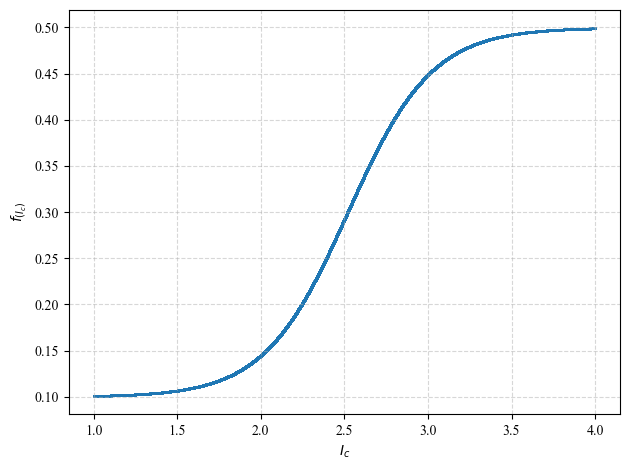

In [ ]:
# plot out f_Ic_contrain vs Ic_CPT_valid
x = result.x
f_Ic_constrain = 0.1 + 0.4 * (1 / (1 + np.exp(-x[1] * (Ic_CPT_valid - x[2]))))

plt.scatter(Ic_CPT_valid, f_Ic_constrain, s = 1)
plt.xlabel('$I_c$')
plt.ylabel('$f_{(I_c)}$')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [15]:
residual_4 = result.fun

In [16]:
# match the residual with tt_ids_CPT_valid and lay_id_assign_valid
residual_df = pd.DataFrame({
    'travelTimeMeta_ID': tt_ids,
    'Geology_ID': group_ids,
    'residual': residual_4
})

Define binned mean function

In [17]:
def binned_means(x, y, Nbins):
    x = np.asarray(x)
    y = np.asarray(y)
    indices = np.argsort(x)
    x_sorted = x[indices]
    y_sorted = y[indices]
    x_sub = np.array_split(x_sorted, Nbins)
    y_sub = np.array_split(y_sorted, Nbins)
    mu_x = np.empty(Nbins, dtype=float)
    mu_y = np.empty(Nbins, dtype=float)
    se_y = np.empty(Nbins, dtype=float)
    for i in range(Nbins):
        mu_x[i] = np.mean(x_sub[i])
        mu_y[i] = np.mean(y_sub[i])
        se_y[i] = np.std(y_sub[i]) / np.sqrt(len(y_sub[i]))
    return (mu_x, mu_y, se_y)

plot out residuals for baseline model (interval velocity residuals vs travel time averaged CPT parameters)

C:\Users\riggs\AppData\Local\Temp\ipykernel_11000\3350104368.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color_map = plt.cm.get_cmap('tab10')  # 10 discrete colors


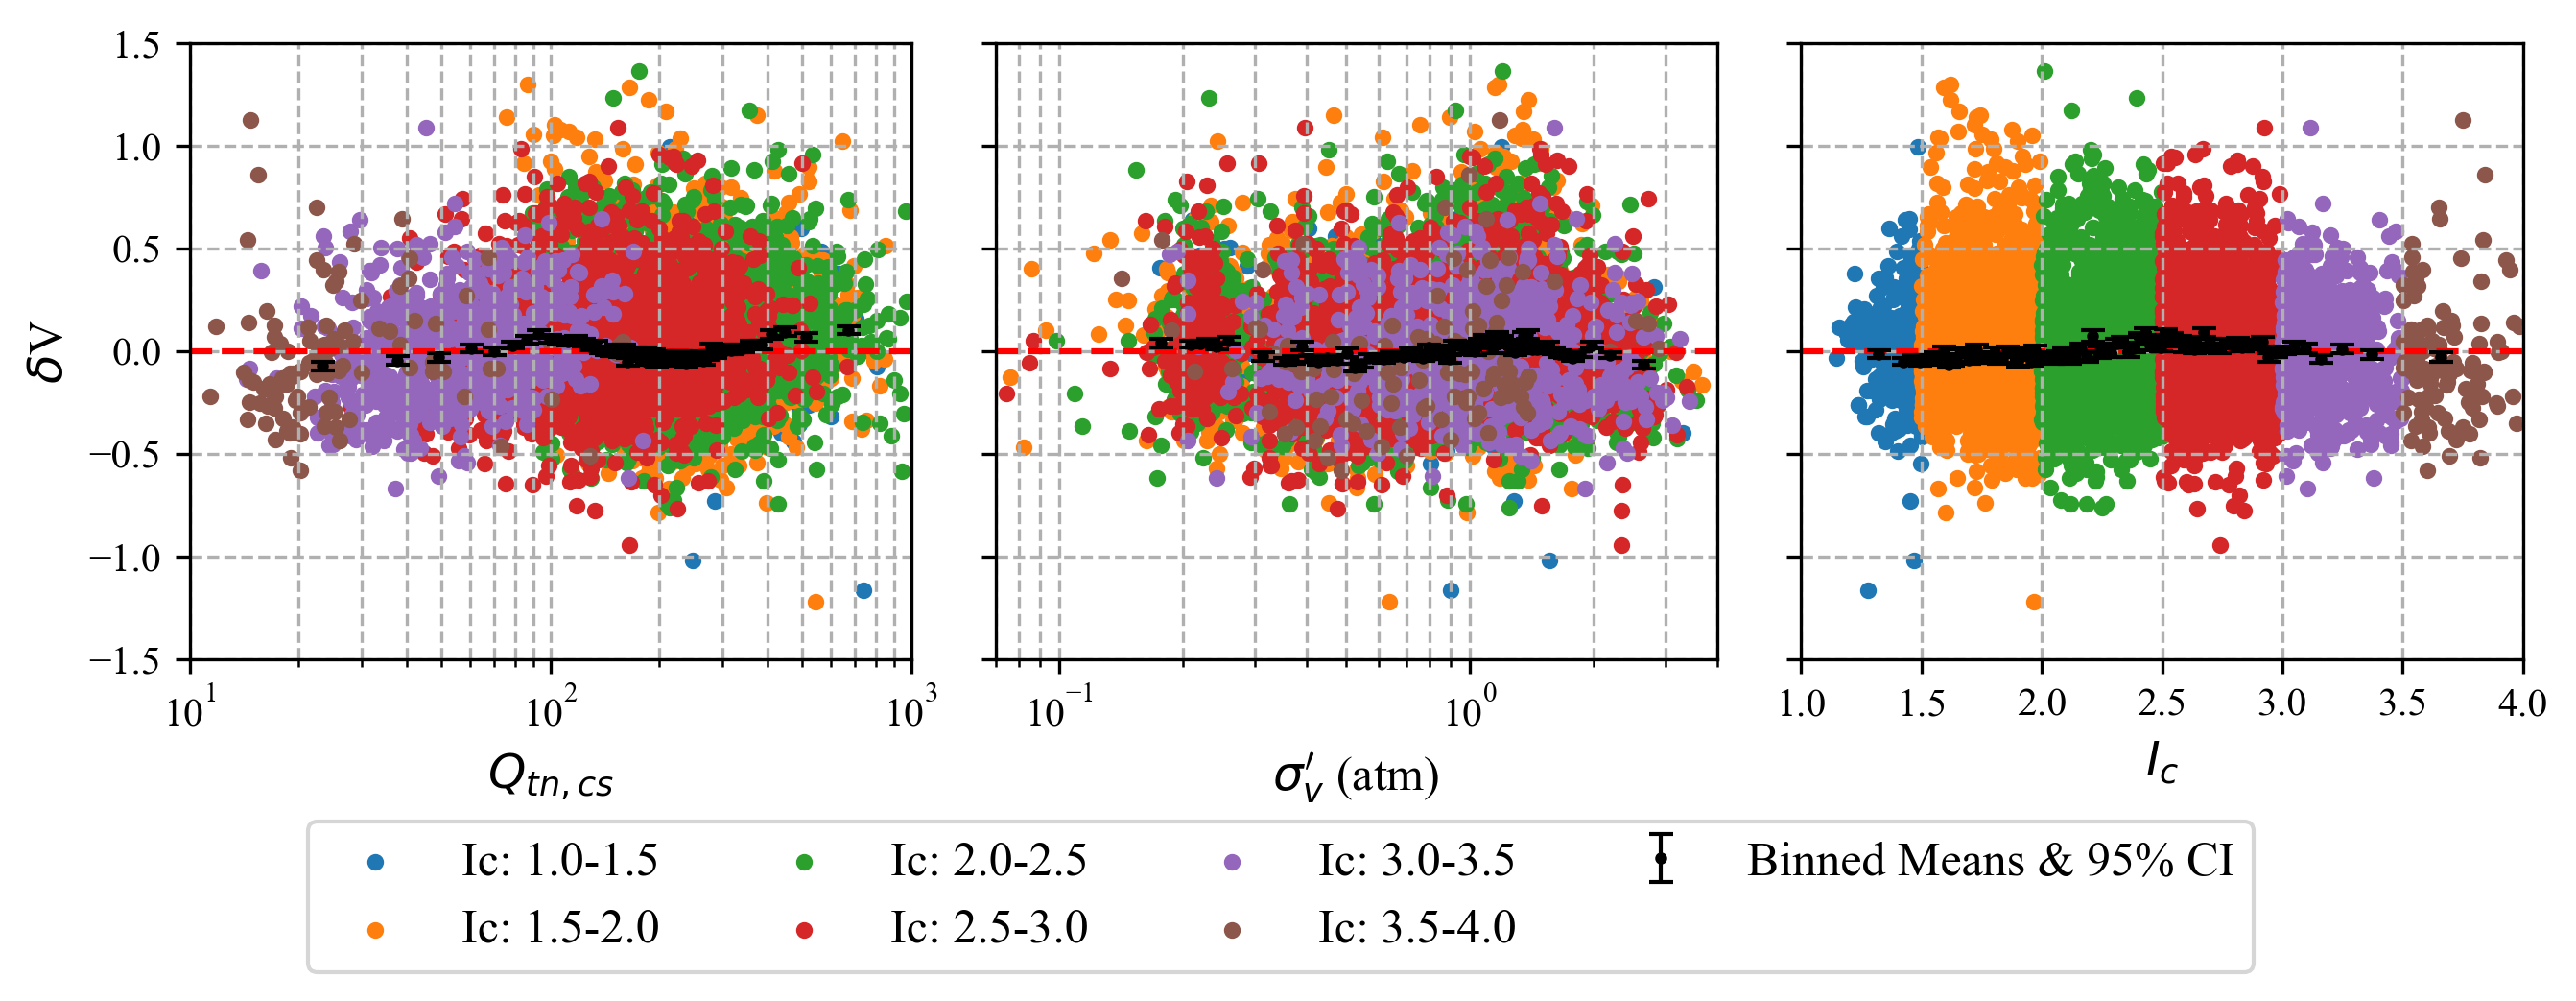

In [ ]:
# plot out residual vs qt, residual vs fz, residual vs ic
color_map = plt.cm.get_cmap('tab10') 
Ic_bins = np.arange(1, 4.5, 0.5) 
Ic_colors = np.digitize(Ic, Ic_bins)

fig, axs = plt.subplots(1, 3, figsize=(9, 3), dpi = 300, sharey = True)

# Residuals vs qt
for i in range (1, len(Ic_bins)):
    mask = Ic_colors == i
    axs[0].scatter(Qtncs[mask], residual_4[mask], label=f'Ic: {Ic_bins[i-1]}-{Ic_bins[i]}', alpha=1, s = 10)

axs[0].set_xlabel('$Q_{tn,cs}$', fontsize = 12)
axs[0].set_ylabel('$\delta$V', fontsize = 12)
axs[0].set_xlim(10, 1000)
axs[0].axhline(0, color='red', linestyle='--')
axs[0].set_xscale('log')
axs[0].set_yscale('linear')
axs[0].grid(True, which="both", ls="--")

mu_qt, mu_residuals, se_residuals = binned_means(Qtncs, residual_4, 60)
axs[0].errorbar(mu_qt, mu_residuals, yerr=0.95 * se_residuals, fmt='.', color = 'black', linewidth=1, markersize=4, capsize=3, label = 'Binned Means & 95% CI')

# Residuals vs fz
for i in range (1, len(Ic_bins)):
    mask = Ic_colors == i
    axs[1].scatter(fz[mask], residual_4[mask], label=f'Ic: {Ic_bins[i-1]}-{Ic_bins[i]}', alpha=1, s = 10)

axs[1].set_xlabel('$\sigma_v^{\prime}$ (atm)', fontsize = 12)
axs[1].axhline(0, color='red', linestyle='--')
axs[1].set_xscale('log')
axs[1].set_yscale('linear')
axs[1].set_xlim(0.07, 4)
axs[1].grid(True, which="both", ls="--")

mu_fz, mu_residuals_fz, se_residuals_fz = binned_means(fz, residual_4, 60)
axs[1].errorbar(mu_fz, mu_residuals_fz, yerr=0.95 * se_residuals_fz, fmt='.', color = 'black', linewidth=1, markersize=4, capsize=3)

# Residuals vs Ic
for i in range (1, len(Ic_bins)):
    mask = Ic_colors == i
    scatter = axs[2].scatter(Ic[mask], residual_4[mask], label=f'Ic: {Ic_bins[i-1]}-{Ic_bins[i]}', alpha=1, s = 10)

axs[2].set_xlabel('$I_{c}$', fontsize = 12)
axs[2].axhline(0, color='red', linestyle='--')
axs[2].set_xlim(1, 4)
axs[2].set_xscale('linear')
axs[2].set_yscale('linear')
axs[2].grid(True, which="both", ls="--")

mu_Ic, mu_residuals_Ic, se_residuals_Ic = binned_means(Ic, residual_4, 80)

axs[2].errorbar(mu_Ic, mu_residuals_Ic, yerr=0.95 * se_residuals_Ic, fmt='.', color = 'black', linewidth=1, markersize=4, capsize=3)

for ax in axs:
    ax.set_ylim(-1.5, 1.5)

# Add legend
handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=4, bbox_to_anchor=(0.5, -0.17), fontsize = 12)

plt.tight_layout()
plt.show()

fig.savefig('Residuals_vs_Qtncs_fz_Ic.png', dpi=300, bbox_inches='tight')

plot out residuals for baseline model in selected geology group (interval velocity residuals vs travel time averaged CPT parameters)

6
8
10


C:\Users\riggs\AppData\Local\Temp\ipykernel_11000\3599334005.py:13: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color_map = plt.cm.get_cmap('tab10')  # 10 discrete colors


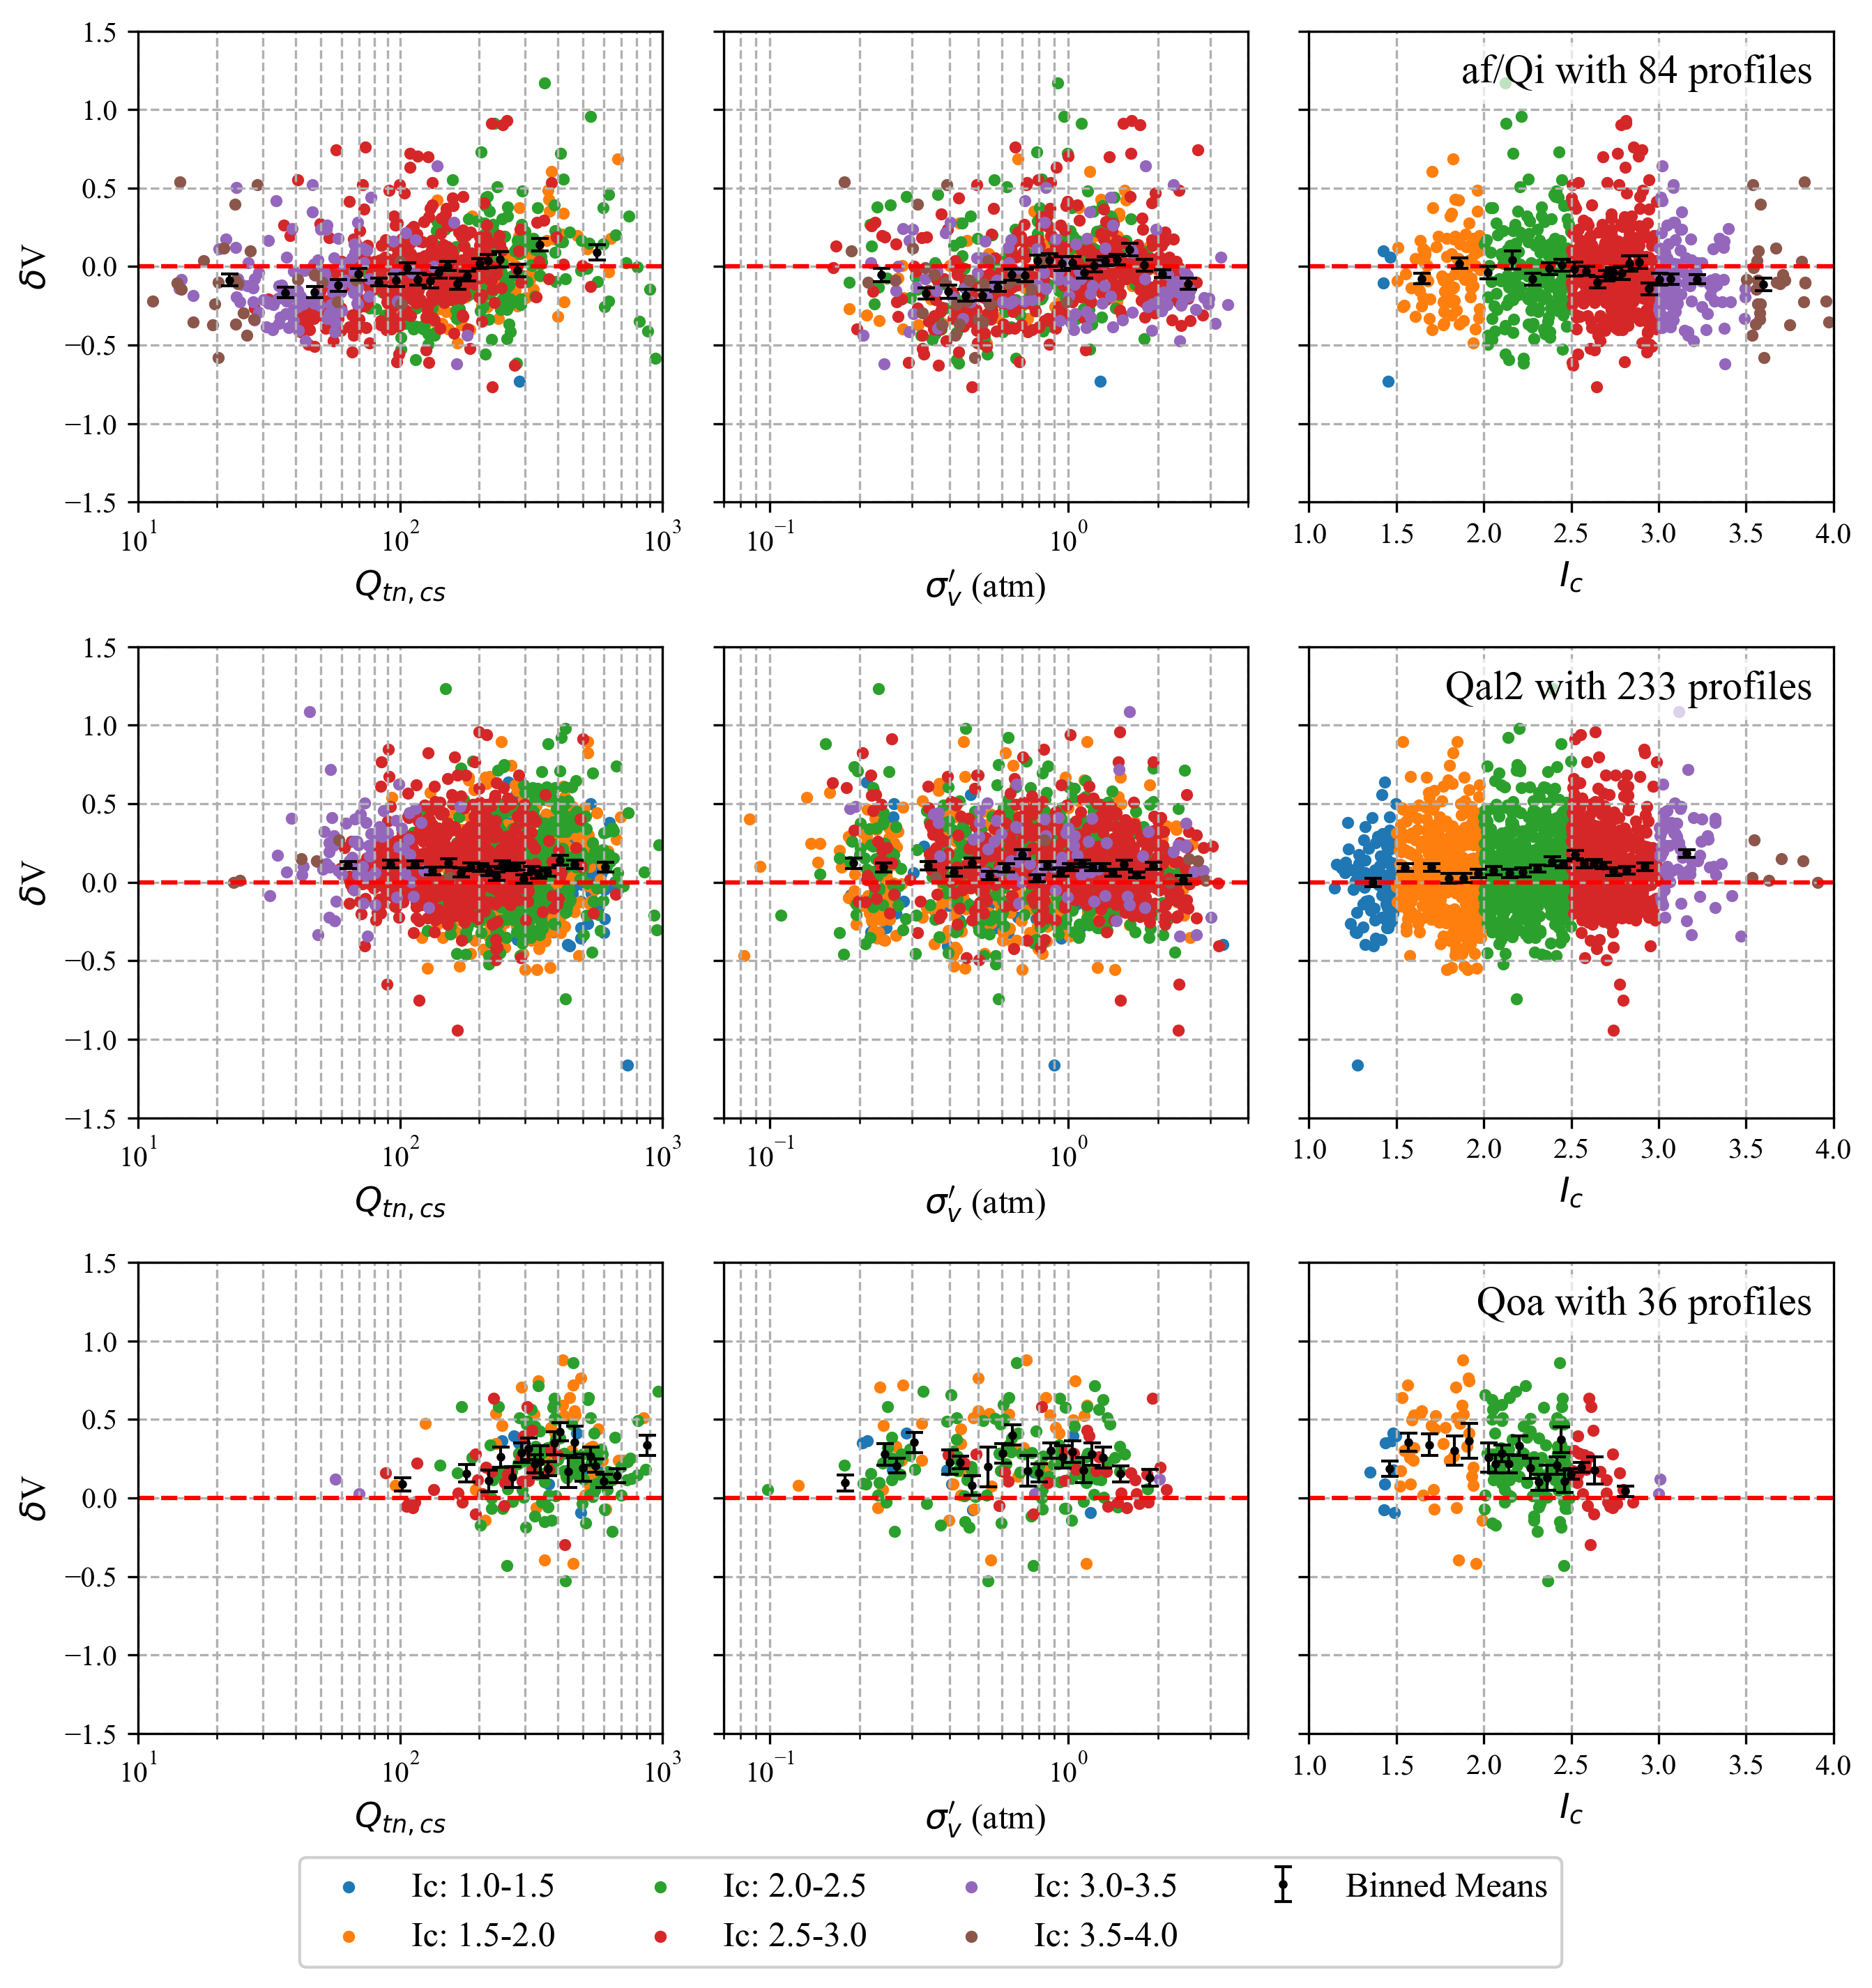

In [ ]:
# repeat this for each geology ID
unique_geology_ids = [6, 8, 10]

fig, axs = plt.subplots(len(unique_geology_ids), 3, figsize=(9, 3 * len(unique_geology_ids)), dpi = 300, sharey = True)

for j in range(1, len(unique_geology_ids) + 1 ):

    k = unique_geology_ids[j-1]
    print (k)
    mask1 = (group_ids == k)
    color_map = plt.cm.get_cmap('tab10')
    Ic_bins = np.arange(1, 4.5, 0.5) 
    Ic_colors = np.digitize(Ic[mask1], Ic_bins)

    row_label = f'{group_text[mask1][0]} with {len(np.unique(tt_ids[mask1]))} profiles'
    axs[j-1][2].text(
        0.96, 0.95, row_label,
        transform=axs[j-1][2].transAxes,
        ha='right', va='top',
        fontsize=14,
        bbox=dict(facecolor='white', edgecolor='none', alpha=0.7)
    )

    # Residuals vs qt
    for i in range (1, len(Ic_bins)):
        mask = Ic_colors == i
        axs[j-1][0].scatter(Qtncs[mask1][mask], residual_4[mask1][mask], label=f'Ic: {Ic_bins[i-1]}-{Ic_bins[i]}', alpha=1, s = 10)

    axs[j-1][0].set_xlabel('$Q_{tn,cs}$', fontsize=12)
    axs[j-1][0].set_ylabel('$\delta$V', fontsize=12)
    axs[j-1][0].set_xlim(10, 1000)
    axs[j-1][0].axhline(0, color='red', linestyle='--')
    axs[j-1][0].set_xscale('log')
    axs[j-1][0].set_yscale('linear')
    axs[j-1][0].grid(True, which="both", ls="--")

    mu_qt, mu_residuals, se_residuals = binned_means(Qtncs[mask1], residual_4[mask1], 20)
    axs[j-1][0].errorbar(mu_qt, mu_residuals, yerr=0.95 * se_residuals, fmt='.', color = 'black', linewidth=1, markersize=4, capsize=3, label = 'Binned Means')

    # Residuals vs fz
    for i in range (1, len(Ic_bins)):
        mask = Ic_colors == i
        axs[j-1][1].scatter(fz[mask1][mask], residual_4[mask1][mask], label=f'Ic: {Ic_bins[i-1]}-{Ic_bins[i]}', alpha=1, s = 10)

    axs[j-1][1].set_xlabel('$\sigma_v^{\prime}$ (atm)', fontsize=12)
    axs[j-1][1].axhline(0, color='red', linestyle='--')
    axs[j-1][1].set_xscale('log')
    axs[j-1][1].set_yscale('linear')
    axs[j-1][1].set_xlim(0.07, 4)
    axs[j-1][1].grid(True, which="both", ls="--")

    mu_fz, mu_residuals_fz, se_residuals_fz = binned_means(fz[mask1], residual_4[mask1], 20)
    axs[j-1][1].errorbar(mu_fz, mu_residuals_fz, yerr=0.95 * se_residuals_fz, fmt='.', color = 'black', linewidth=1, markersize=4, capsize=3)

    # Residuals vs Ic
    for i in range (1, len(Ic_bins)):
        mask = Ic_colors == i
        axs[j-1][2].scatter(Ic[mask1][mask], residual_4[mask1][mask], label=f'Ic: {Ic_bins[i-1]}-{Ic_bins[i]}', alpha=1, s = 10)

    axs[j-1][2].set_xlabel('$I_{c}$', fontsize=12)
    axs[j-1][2].axhline(0, color='red', linestyle='--')
    axs[j-1][2].set_xlim(1, 4.0)
    axs[j-1][2].set_xscale('linear')
    axs[j-1][2].set_yscale('linear')
    axs[j-1][2].grid(True, which="both", ls="--")

    mu_Ic, mu_residuals_Ic, se_residuals_Ic = binned_means(Ic[mask1], residual_4[mask1], 20)

    axs[j-1][2].errorbar(mu_Ic, mu_residuals_Ic, yerr=0.95 * se_residuals_Ic, fmt='.', color = 'black', linewidth=1, markersize=4, capsize=3)

    for ax_row in axs:
        for ax in ax_row:
            ax.set_ylim(-1.5, 1.5)

    # Add legend of the Ic ranges to the bottom of the figure
    handles, labels = axs[j-1][0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', ncol=4, bbox_to_anchor=(0.5, -0.06), fontsize = 12)

plt.tight_layout()
plt.show()

fig.savefig('Residuals_by_Geology.png', dpi=300, bbox_inches='tight')

only plot out residuals vs Ic (Selected geology group)

6
8
10


C:\Users\riggs\AppData\Local\Temp\ipykernel_11000\1575966065.py:13: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color_map = plt.cm.get_cmap('tab10')  # 10 discrete colors


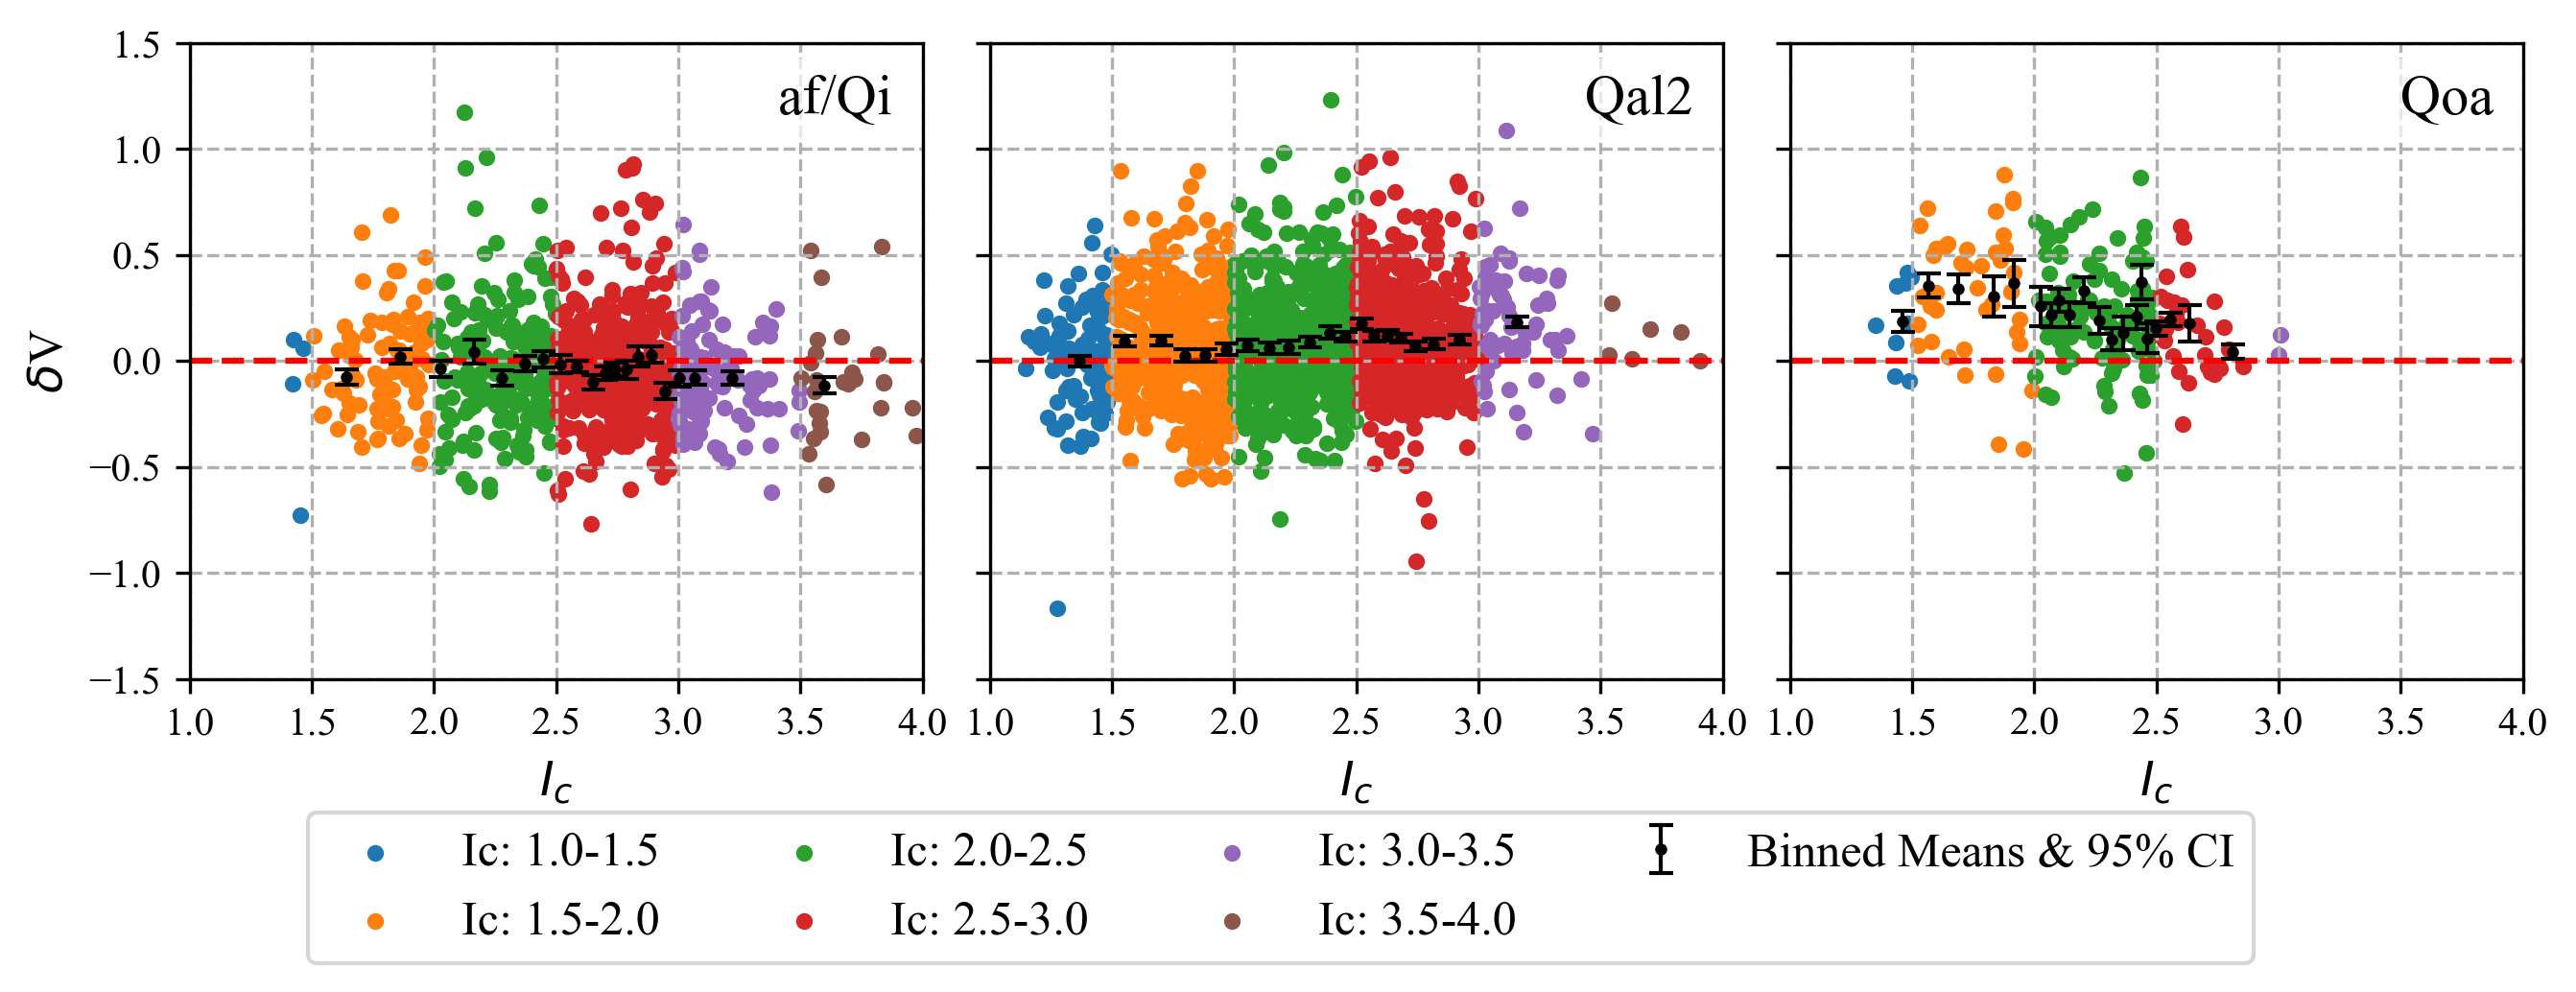

In [ ]:
unique_geology_ids = [6, 8, 10]

fig, axs = plt.subplots(1, len(unique_geology_ids), figsize=(9, 3), dpi = 300, sharey = True)

for j in range(1, len(unique_geology_ids) + 1 ):

    k = unique_geology_ids[j-1]
    print (k)
    mask1 = (group_ids == k)
    color_map = plt.cm.get_cmap('tab10')  # 10 discrete colors

    # Assign colors based on Ic ranges
    Ic_bins = np.arange(1, 4.5, 0.5)  # Ranges from 0 to 5 with step 0.5
    Ic_colors = np.digitize(Ic[mask1], Ic_bins)


    row_label = f'{group_text[mask1][0]}'
    # with {len(np.unique(tt_ids[mask1]))} profiles'
    axs[j-1].text(
        0.96, 0.95, row_label,
        transform=axs[j-1].transAxes,
        ha='right', va='top',
        fontsize=14,
        bbox=dict(facecolor='white', edgecolor='none', alpha=0.7)
    )

    # Residuals vs Ic
    for i in range (1, len(Ic_bins)):
        mask = Ic_colors == i
        axs[j-1].scatter(Ic[mask1][mask], residual_4[mask1][mask], label=f'Ic: {Ic_bins[i-1]}-{Ic_bins[i]}', alpha=1, s = 10)

    axs[j-1].set_xlabel('$I_{c}$', fontsize=12)
    # axs[j-1][2].set_ylabel('Residuals')
    # axs[j-1][2].set_title('Residuals vs Ic')
    axs[j-1].axhline(0, color='red', linestyle='--')
    axs[j-1].set_xlim(1, 4.0)
    axs[j-1].set_xscale('linear')
    axs[j-1].set_yscale('linear')
    axs[j-1].grid(True, which="both", ls="--")

    mu_Ic, mu_residuals_Ic, se_residuals_Ic = binned_means(Ic[mask1], residual_4[mask1], 20)

    axs[j-1].errorbar(mu_Ic, mu_residuals_Ic, yerr=0.95 * se_residuals_Ic, fmt='.', color = 'black', linewidth=1, markersize=4, capsize=3, label = 'Binned Means & 95% CI')

    # Share the same y-axis for all subplots
    for ax in axs:
            ax.set_ylim(-1.5, 1.5)

axs[0].set_ylabel('$\delta$V', fontsize=12)

# Add legend of the Ic ranges to the bottom of the figure
handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=4, bbox_to_anchor=(0.5, -0.16), fontsize = 12)

plt.tight_layout()
plt.show()

fig.savefig('Residuals_by_Geology.png', dpi=300, bbox_inches='tight')

plot out residuals for baseline model in each Ic ranges

/var/folders/vj/kz200_g56fs3r6vb7kwg72540000gn/T/ipykernel_56514/2054957034.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color_map = plt.cm.get_cmap('tab10')  # 10 discrete colors


slope 0.08269085203098801 intercept -0.5101270108459973
slope 0.029419554887596813 intercept -0.1869611455502962
slope 0.05090340514352312 intercept -0.2667268179658782
slope 0.042854561481536366 intercept -0.17940605336003795
slope 0.13196784652076127 intercept -0.5319176611599726
slope 0.015115672631270529 intercept -0.07282290450955817


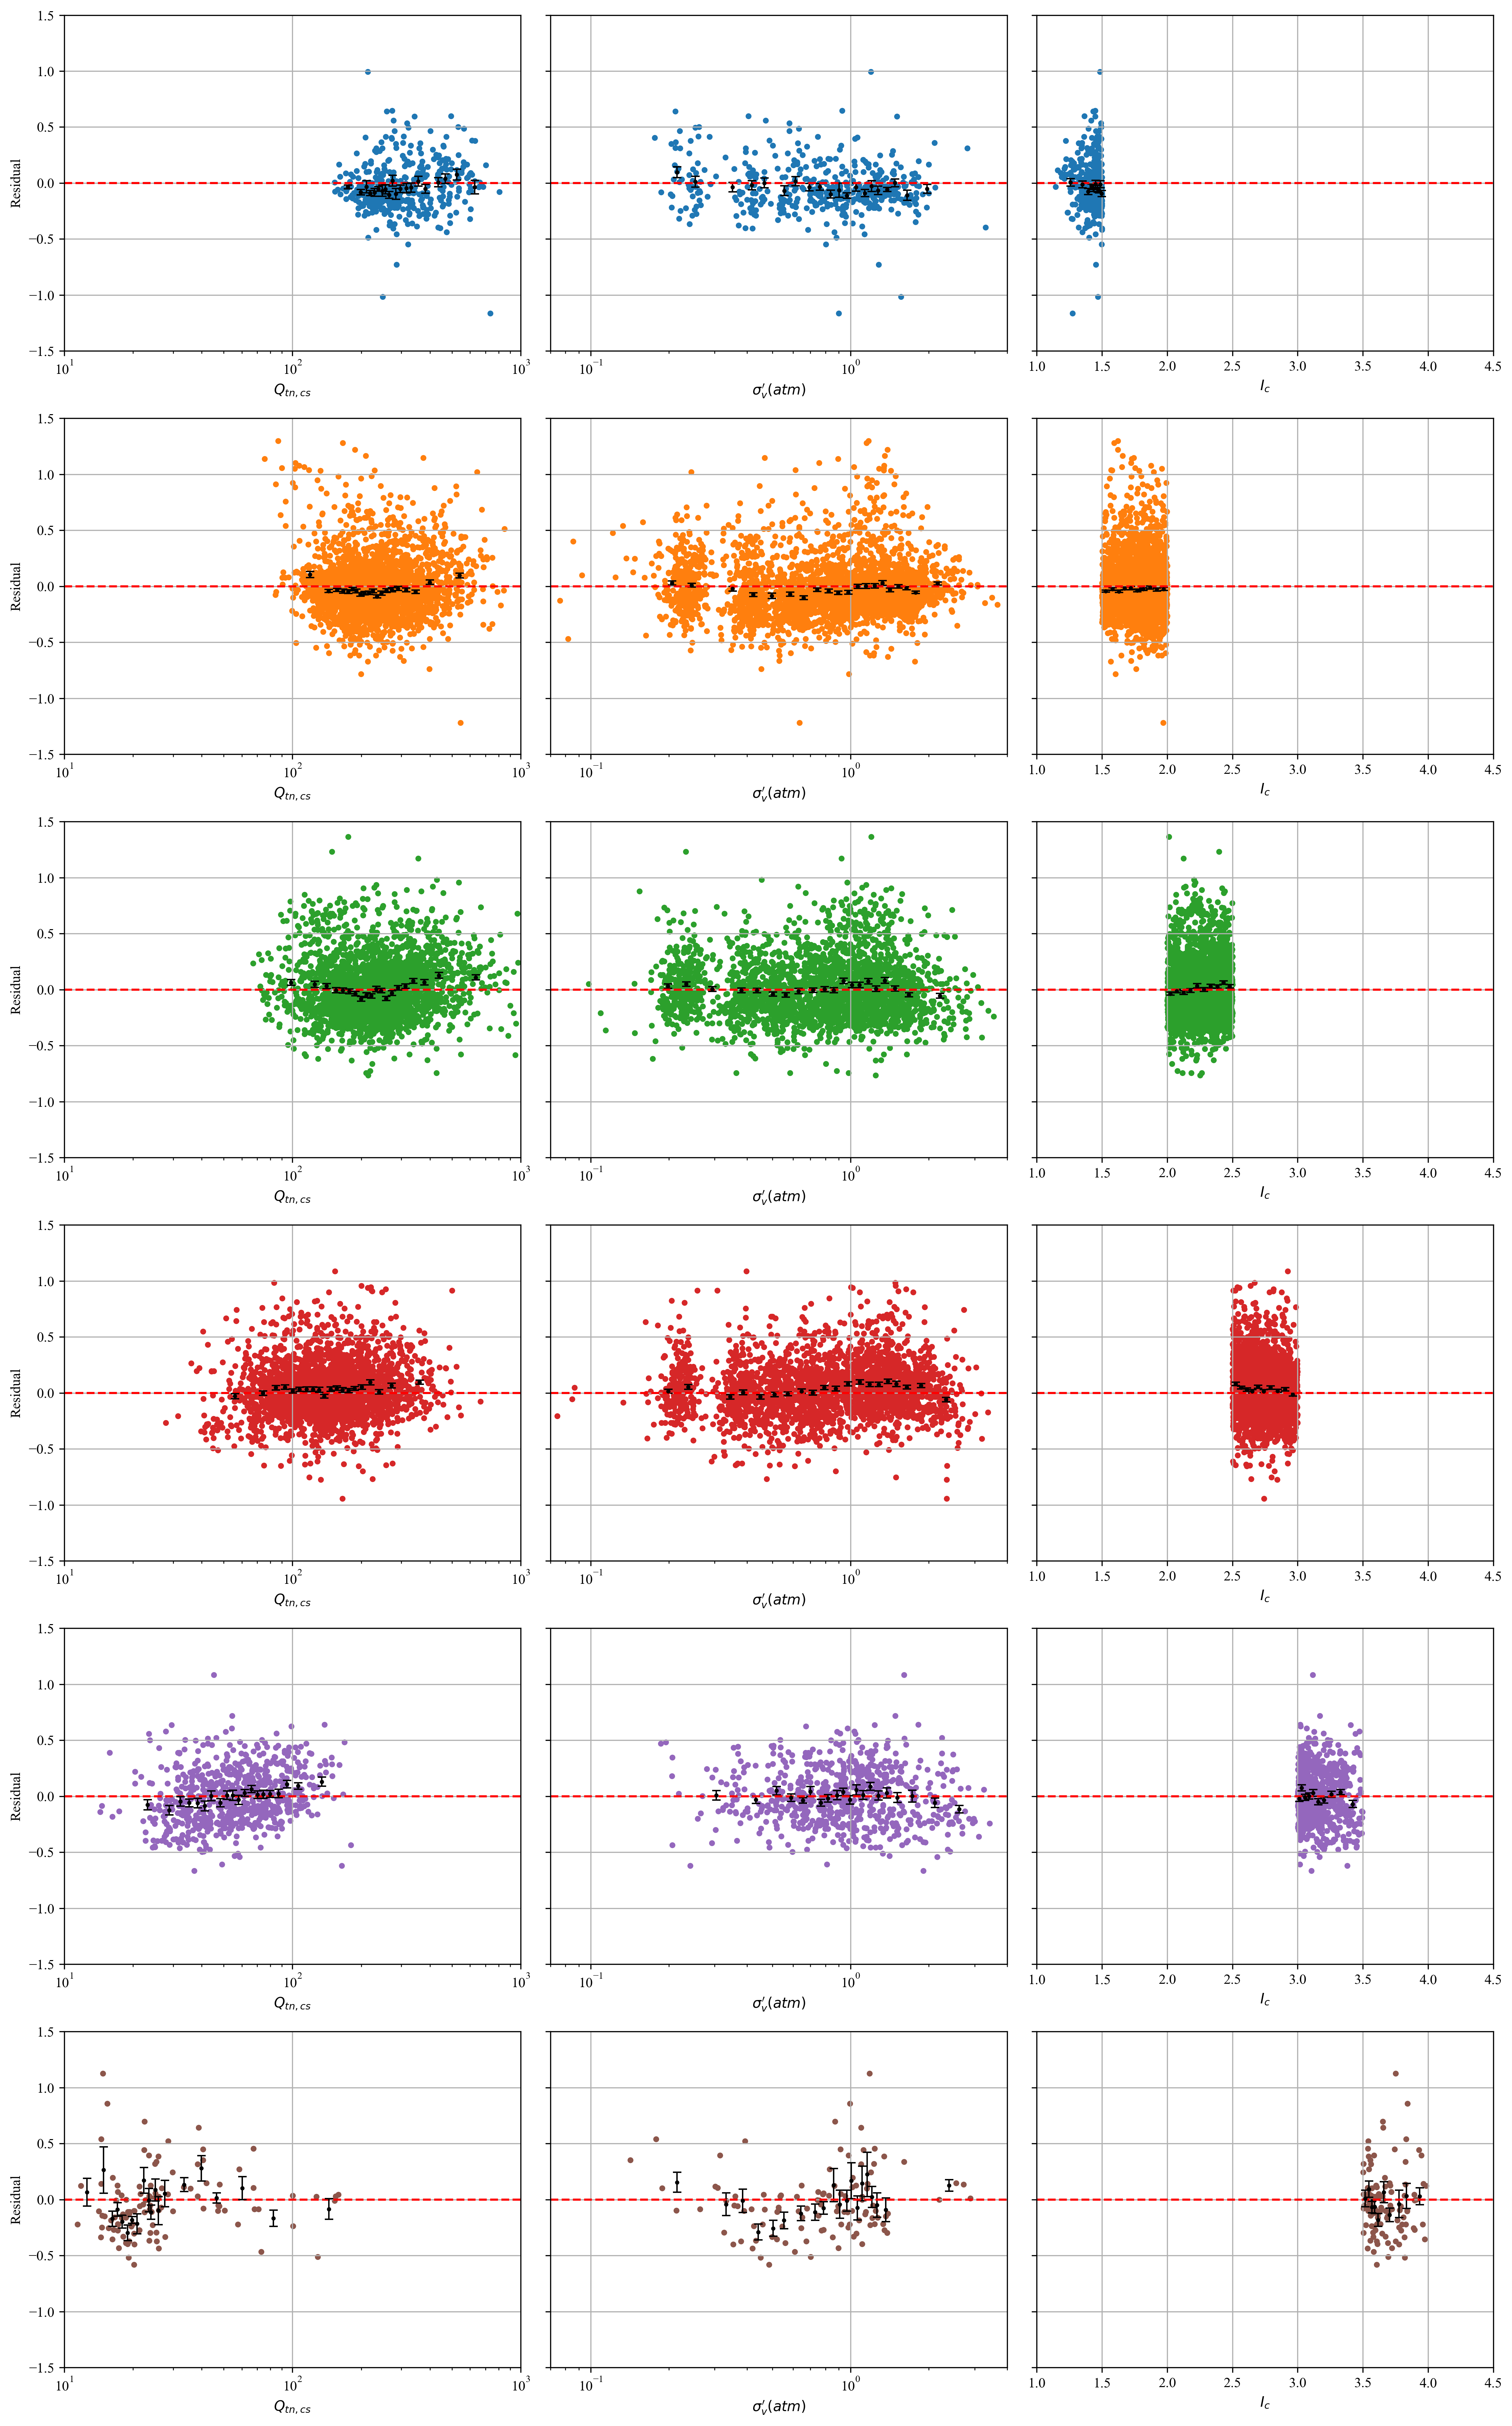

In [118]:
# plot out residual vs Qtncs, residual vs fz, residual vs ic
color_map = plt.cm.get_cmap('tab10')  # 10 discrete colors

# Assign colors based on Ic ranges
Ic_bins = np.arange(1, 4.5, 0.5)  # Ranges from 0 to 5 with step 0.5
Ic_colors = np.digitize(Ic, Ic_bins)

fig, axs = plt.subplots(6, 3, figsize=(15, 24), dpi=300, sharey = True)

slope_Qtncs = []

# Residuals Vs Qtncs
for i in range(1, len(Ic_bins)):
    mask = Ic_colors == i
    color = color_map(i - 1)
    axs[i-1][0].scatter(Qtncs[mask], residual_4[mask], label=f'$I_c$: {Ic_bins[i-1]}-{Ic_bins[i]}', alpha=1, s=10, color=color)
    axs[i-1][0].axhline(0, color='red', linestyle='--')
    mu_Qtn, mu_residual, se_residual = binned_means(Qtncs[mask], residual_4[mask], 20)

    x = np.log(mu_Qtn)
    y = mu_residual
    model = LinearRegression()
    model.fit(x.reshape(-1, 1), y)
    print('slope', model.coef_[0], 'intercept', model.intercept_)
    slope_Qtncs.append(model.coef_[0])

    axs[i-1][0].errorbar(mu_Qtn, mu_residual, yerr=0.95 * se_residual, fmt='.', color='black', linewidth=1, markersize=4, capsize=3, label='Binned Mean ± 95% SE')
    axs[i-1][0].set_xscale('log')
    axs[i-1][0].set_xlim(10, 1000)
    axs[i-1][0].set_xlabel('$Q_{tn,cs}$')
    axs[i-1][0].set_ylabel('Residual')
    axs[i-1][0].grid(True)

# Residuals vs fz
for i in range(1, len(Ic_bins)):
    mask = Ic_colors == i
    color = color_map(i - 1) 
    axs[i-1][1].scatter(fz[mask], residual_4[mask], label=f'$I_c$: {Ic_bins[i-1]}-{Ic_bins[i]}', alpha=1, s=10, color=color)
    mu_fz, mu_residual, se_residual = binned_means(fz[mask], residual_4[mask], 20)
    axs[i-1][1].errorbar(mu_fz, mu_residual, yerr=0.95 * se_residual, fmt='.', color='black', linewidth=1, markersize=4, capsize=3, label='Binned Mean ± 95% SE')
    axs[i-1][1].set_xscale('log')
    axs[i-1][1].set_xlim(0.07, 4)
    axs[i-1][1].axhline(0, color='red', linestyle='--')
    axs[i-1][1].set_xlabel('$\sigma_v^{\prime} (atm)$')
    axs[i-1][1].grid(True)

for i in range(1, len(Ic_bins)):
    mask = Ic_colors == i
    color = color_map(i - 1)  # Assign color based on row index
    axs[i-1][2].scatter(Ic[mask], residual_4[mask], label=f'$I_c$: {Ic_bins[i-1]}-{Ic_bins[i]}', alpha=1, s=10, color=color)

    mu_Ic, mu_residual, se_residual = binned_means(Ic[mask], residual_4[mask], 10)
    axs[i-1][2].errorbar(mu_Ic, mu_residual, yerr=0.95 * se_residual, fmt='.', color='black', linewidth=1, markersize=4, capsize=3, label='Binned Mean ± 95% SE')
    axs[i-1][2].axhline(0, color='red', linestyle='--')
    axs[i-1][2].set_xlabel('$I_c$')
    axs[i-1][2].grid(True)
    axs[i-1][2].set_xlim(1, 4.5)

# Share the same y-axis for all subplots
for ax in axs.flatten():
    ax.set_ylim(-1.5, 1.5)

plt.tight_layout()
plt.show()

# Mixed Effects Regression

#### Regression 1: Only geology, no profile-to-profile

In [ ]:
def weighted_velocity_geo (x, Qtncs_geo, fz_geo, Ic_geo, lay_id_assign_geo, Vsi_geo, group_filters):

    f_Ic_constrain = 0.1 + 0.4 * (1 / (1 + np.exp(- x[1] * (Ic_geo - x[2]))))
    cpt_velocity = x[0] * np.log(Qtncs_geo) + f_Ic_constrain * np.log(fz_geo) + sum(group_filters[group] * x[2 + group] for group in group_filters)

    cpt_slowness = 1 / np.exp(cpt_velocity)
    dz = np.repeat(0.05, len(cpt_velocity))

    layer_slowness = np.bincount(lay_id_assign_geo, weights=cpt_slowness * dz)
    layer_thickness = np.bincount(lay_id_assign_geo, weights=dz)
    layer_velocity = layer_thickness / layer_slowness

    layer_velocity = layer_thickness / layer_slowness

    residual = np.log(Vsi_geo) - np.log(layer_velocity)

    return residual

In [ ]:
unique_geology_ids = np.unique(group_ids)

x0 = [0.27370871, 3.78136997, 2.48307888] + [4.1] * len(unique_geology_ids)

from scipy.optimize import least_squares
import time
start_time = time.time()
import scipy as sp

result_geo = least_squares(weighted_velocity_geo, x0, args=(Qtncs_CPT_valid, fz_CPT_valid, Ic_CPT_valid, lay_id_assign_valid, Vsi, group_filters))
end_time = time.time()
print(f"Optimization completed in {end_time - start_time:.2f} seconds")
print(f"b1 = {result_geo.x[0]:.4f}")
print(f"b2 = {result_geo.x[1]:.4f}")
print(f"b3 = {result_geo.x[2]:.4f}")
for i, group in enumerate(unique_geology_ids):
    print(f"Geology {group} ({group_text[group_ids == group][0]}): a{i+1} = {result_geo.x[3 + i]:.4f}")

print(f"\nResidual std: {np.std(result_geo.fun):.4f}")



Optimization completed in 2.20 seconds
b1 = 0.2417
b2 = 2.3596
b3 = 2.5629
Geology 1 (Beach_Dune): a1 = 4.3573
Geology 2 (Floodplain): a2 = 4.2239
Geology 3 (Glacial): a3 = 4.1688
Geology 4 (Lagoonal): a4 = 4.1604
Geology 5 (Valley_Train): a5 = 4.1979
Geology 6 (af/Qi): a6 = 4.2232
Geology 7 (Qal1): a7 = 4.3060
Geology 8 (Qal2): a8 = 4.3754
Geology 9 (Qal3): a9 = 4.3119
Geology 10 (Qoa): a10 = 4.5332
Geology 11 (Qs): a11 = 4.3605

Residual std: 0.2331


In [15]:
residual_4 = result_geo.fun

/var/folders/vj/kz200_g56fs3r6vb7kwg72540000gn/T/ipykernel_56514/4135302014.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color_map = plt.cm.get_cmap('tab10')  # 10 discrete colors


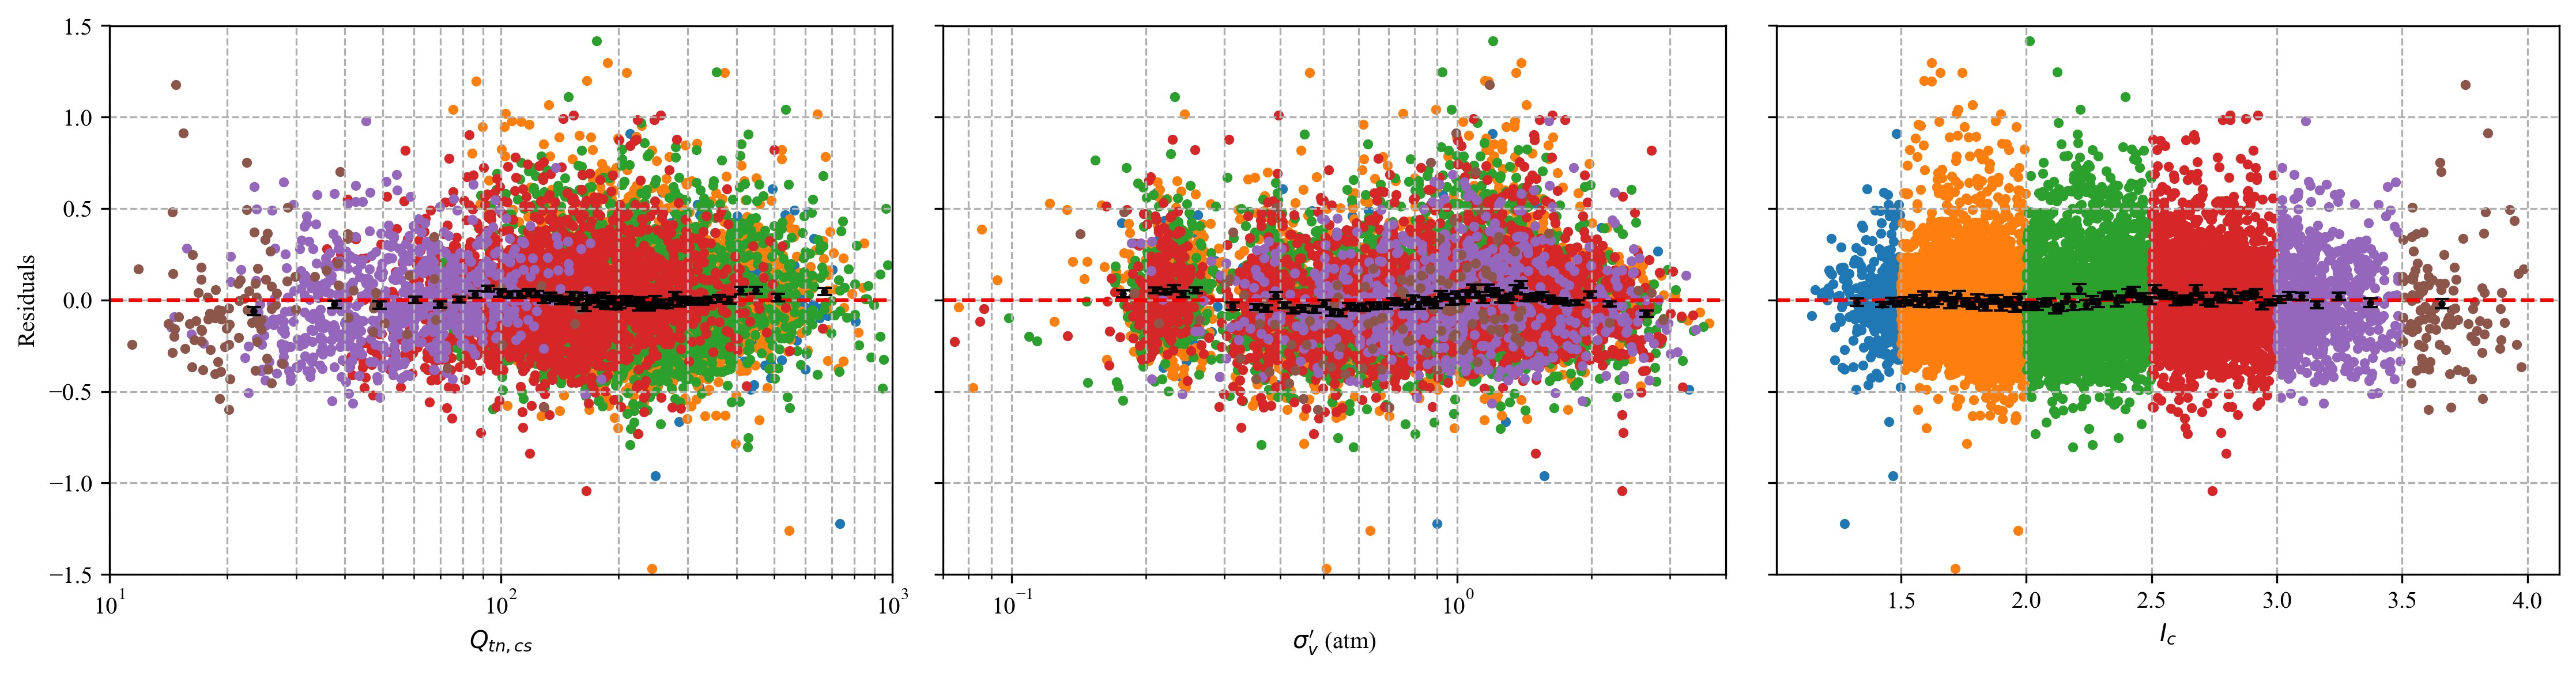

In [ ]:
color_map = plt.cm.get_cmap('tab10')
Ic_bins = np.arange(1, 100, 0.5) 
Ic_colors = np.digitize(Ic, Ic_bins)

fig, axs = plt.subplots(1, 3, figsize=(15, 4), dpi = 300, sharey = True)

# Residuals vs qt
for i in range (1, len(Ic_bins)):
    mask = Ic_colors == i
    axs[0].scatter(Qtncs[mask], residual_4[mask], label=f'Ic: {Ic_bins[i-1]}-{Ic_bins[i]}', alpha=1, s = 10)

axs[0].set_xlabel('$Q_{tn,cs}$')
axs[0].set_ylabel('Residuals')
axs[0].set_xlim(10, 1000)
axs[0].axhline(0, color='red', linestyle='--')
axs[0].set_xscale('log')
axs[0].set_yscale('linear')
axs[0].grid(True, which="both", ls="--")

mu_qt, mu_residuals, se_residuals = binned_means(Qtncs, residual_4, 60)
axs[0].errorbar(mu_qt, mu_residuals, yerr=0.95 * se_residuals, fmt='.', color = 'black', linewidth=1, markersize=4, capsize=3, label = 'Binned Mean')

# Residuals vs fz
for i in range (1, len(Ic_bins)):
    mask = Ic_colors == i
    axs[1].scatter(fz[mask], residual_4[mask], label=f'Ic: {Ic_bins[i-1]}-{Ic_bins[i]}', alpha=1, s = 10)

axs[1].set_xlabel('$\sigma_v^{\prime}$ (atm)')
axs[1].axhline(0, color='red', linestyle='--')
axs[1].set_xscale('log')
axs[1].set_yscale('linear')
axs[1].set_xlim(0.07, 4)
axs[1].grid(True, which="both", ls="--")

mu_fz, mu_residuals_fz, se_residuals_fz = binned_means(fz, residual_4, 60)
axs[1].errorbar(mu_fz, mu_residuals_fz, yerr=0.95 * se_residuals_fz, fmt='.', color = 'black', linewidth=1, markersize=4, capsize=3)

# Residuals vs Ic
for i in range (1, len(Ic_bins)):
    mask = Ic_colors == i
    scatter = axs[2].scatter(Ic[mask], residual_4[mask], label=f'Ic: {Ic_bins[i-1]}-{Ic_bins[i]}', alpha=1, s = 10)

axs[2].set_xlabel('$I_{c}$')
axs[2].axhline(0, color='red', linestyle='--')
axs[2].set_xscale('linear')
axs[2].set_yscale('linear')
axs[2].grid(True, which="both", ls="--")

mu_Ic, mu_residuals_Ic, se_residuals_Ic = binned_means(Ic, residual_4, 80)

axs[2].errorbar(mu_Ic, mu_residuals_Ic, yerr=0.95 * se_residuals_Ic, fmt='.', color = 'black', linewidth=1, markersize=4, capsize=3)

# Share the same y-axis for all subplots
for ax in axs:
    ax.set_ylim(-1.5, 1.5)

# Add legend
handles, labels = axs[0].get_legend_handles_labels()

plt.tight_layout()
plt.show()

In [ ]:
# repeat this for each geology ID
unique_geology_ids = np.unique(group_ids)

fig, axs = plt.subplots(11, 3, figsize=(15, 44), dpi = 300, sharey = True)

for j in unique_geology_ids:

    print (j)
    mask1 = (group_ids == j)
    color_map = plt.cm.get_cmap('tab10')
    Ic_bins = np.arange(1, 100, 0.5)
    Ic_colors = np.digitize(Ic[mask1], Ic_bins)


    row_label = f'{group_text[mask1][0]} with {len(np.unique(tt_ids[mask1]))} profiles'
    axs[j-1][2].text(
        0.98, 0.98, row_label,
        transform=axs[j-1][2].transAxes,
        ha='right', va='top',
        fontsize=14,
        bbox=dict(facecolor='white', edgecolor='none', alpha=0.7)
    )


    # Residuals vs qt
    for i in range (1, len(Ic_bins)):
        mask = Ic_colors == i
        axs[j-1][0].scatter(Qtncs[mask1][mask], residual_4[mask1][mask], label=f'Ic: {Ic_bins[i-1]}-{Ic_bins[i]}', alpha=1, s = 10)

    axs[j-1][0].set_xlabel('$Q_{tn,cs}$')
    axs[j-1][0].set_ylabel('Residuals')
    axs[j-1][0].set_xlim(10, 1000)
    axs[j-1][0].axhline(0, color='red', linestyle='--')
    axs[j-1][0].set_xscale('log')
    axs[j-1][0].set_yscale('linear')
    axs[j-1][0].grid(True, which="both", ls="--")

    mu_qt, mu_residuals, se_residuals = binned_means(Qtncs[mask1], residual_4[mask1], 20)
    axs[j-1][0].errorbar(mu_qt, mu_residuals, yerr=0.95 * se_residuals, fmt='.', color = 'black', linewidth=1, markersize=4, capsize=3, label = 'Binned Mean')

    # Residuals vs fz
    for i in range (1, len(Ic_bins)):
        mask = Ic_colors == i
        axs[j-1][1].scatter(fz[mask1][mask], residual_4[mask1][mask], label=f'Ic: {Ic_bins[i-1]}-{Ic_bins[i]}', alpha=1, s = 10)

    axs[j-1][1].set_xlabel('$\sigma_v^{\prime}$ (atm)')
    axs[j-1][1].axhline(0, color='red', linestyle='--')
    axs[j-1][1].set_xscale('log')
    axs[j-1][1].set_yscale('linear')
    axs[j-1][1].set_xlim(0.07, 4)
    axs[j-1][1].grid(True, which="both", ls="--")

    mu_fz, mu_residuals_fz, se_residuals_fz = binned_means(fz[mask1], residual_4[mask1], 20)
    axs[j-1][1].errorbar(mu_fz, mu_residuals_fz, yerr=0.95 * se_residuals_fz, fmt='.', color = 'black', linewidth=1, markersize=4, capsize=3)

    # Residuals vs Ic
    for i in range (1, len(Ic_bins)):
        mask = Ic_colors == i
        axs[j-1][2].scatter(Ic[mask1][mask], residual_4[mask1][mask], label=f'Ic: {Ic_bins[i-1]}-{Ic_bins[i]}', alpha=1, s = 10)

    axs[j-1][2].set_xlabel('$I_{c}$')
    axs[j-1][2].axhline(0, color='red', linestyle='--')
    axs[j-1][2].set_xscale('linear')
    axs[j-1][2].set_yscale('linear')
    axs[j-1][2].grid(True, which="both", ls="--")

    mu_Ic, mu_residuals_Ic, se_residuals_Ic = binned_means(Ic[mask1], residual_4[mask1], 20)

    axs[j-1][2].errorbar(mu_Ic, mu_residuals_Ic, yerr=0.95 * se_residuals_Ic, fmt='.', color = 'black', linewidth=1, markersize=4, capsize=3)

    for ax_row in axs:
        for ax in ax_row:
            ax.set_ylim(-1.5, 1.5)

plt.tight_layout()
plt.show()

1


/var/folders/vj/kz200_g56fs3r6vb7kwg72540000gn/T/ipykernel_56514/649022796.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color_map = plt.cm.get_cmap('tab10')  # 10 discrete colors


2
3
4
5
6
7
8
9
10
11


Define log normal pdf

In [51]:
# Log-likelihood function for normal probability density function
def L_normal_pdf(x, mu, sigma):
    return -0.5 * len(x) * np.log(2.0 * np.pi * sigma ** 2) - 0.5 / sigma ** 2 * np.sum((x - mu) ** 2)

In [52]:
import scipy as sp

#### Regression 2: No geology, only profile-to-profile (In the paper)

In [ ]:
import numpy as np
from scipy.optimize import least_squares
import time

def calculation_mixed(x, Qtncs_CPT_valid, fz_CPT_valid, Ic_CPT_valid, tt_ids, group_ids, Vsi):

    f_Ic_constrain = 0.1 + 0.4 * (1 / (1 + np.exp(-x[1] * (Ic_CPT_valid - x[2]))))
    cpt_velocity = x[0] * np.log(Qtncs_CPT_valid) + f_Ic_constrain * np.log(fz_CPT_valid) + x[3]

    cpt_slowness = 1 / np.exp(cpt_velocity)
    dz = np.repeat(0.05, len(cpt_velocity))
    layer_slowness = np.bincount(lay_id_assign_valid, weights = cpt_slowness * dz)
    layer_thickness = np.bincount(lay_id_assign_valid, weights = dz)
    layer_velocity = layer_thickness / layer_slowness

    residual = np.log(Vsi) - np.log(layer_velocity)

    unique_tt_ids = np.unique(tt_ids)
    eta_p = np.empty(len(residual), dtype=float)
    for i, unique_tt_id in enumerate(unique_tt_ids):
        eta_p[tt_ids == unique_tt_id] = np.full(len(tt_ids[tt_ids == unique_tt_id]), np.mean(residual[tt_ids == unique_tt_id]))


    Likelihood = L_normal_pdf(residual, 0.0, np.sqrt(x[4]**2 + x[5]**2)) + L_normal_pdf(residual - eta_p, 0, x[5])
    # Likelihood = L_normal_pdf(residual - eta_g - eta_p, 0.0, x[6]) + L_normal_pdf(residual - eta_g, 0, np.sqrt(x[4] ** 2 + x[6] ** 2)) + L_normal_pdf(residual, 0, np.sqrt(x[4] ** 2 + x[5] ** 2 + x[6] ** 2))
    return -Likelihood

In [54]:
x0 = [0.27, 3.5, 2.6, 4.0, 0.2, 0.2]

# full parameter vector
start_time = time.time()
result = sp.optimize.minimize(calculation_mixed, x0, args=(Qtncs_CPT_valid, fz_CPT_valid, Ic_CPT_valid, tt_ids, group_ids, Vsi), bounds=((-10,10),(-10,10),(-10,10),(-10,10), (0.01,1.0),(0.01,1.0)), method='L-BFGS-B', options={'gtol': 1e-15})
end_time = time.time()

b1, b2, b3, a, phi_p2p, phi_ep = result.x
print(f"Regression completed in {end_time - start_time:.2f} seconds")
print ("Fixed effects:")
print("b1 =", b1)
print("b2 =", b2)
print("b3 =", b3)
print("a =", a)
print("\nRandom effects summary:")
print("phi_p2p:", phi_p2p)
print("phi_ep:", phi_ep) 

Regression completed in 12.29 seconds
Fixed effects:
b1 = 0.25844229432308197
b2 = 3.081004364610985
b3 = 2.468577746716974
a = 4.1959735102002425

Random effects summary:
phi_p2p: 0.1515764096015998
phi_ep: 0.19406503092632693


In [55]:
np.sqrt(result.x[4]**2 + result.x[5]**2)

np.float64(0.24624508964880534)

Calculate eta_p2p and plot them in histogram

In [57]:
f_Ic_constrain = 0.1 + 0.4 * (1 / (1 + np.exp(- b2 * (Ic_CPT_valid - b3))))

pred = b1 * np.log(Qtncs_CPT_valid) + f_Ic_constrain * np.log(fz_CPT_valid) + a

cpt_slowness = 1 / np.exp(pred)
dz = np.repeat(0.05, len(pred))
layer_slowness = np.bincount(lay_id_assign_valid, weights = cpt_slowness * dz)
layer_thickness = np.bincount(lay_id_assign_valid, weights = dz)
layer_velocity = layer_thickness / layer_slowness

R = np.log(Vsi) - np.log(layer_velocity)

unique_tt_ids = np.unique(tt_ids)
eta_p = np.empty(len(R), dtype=float)
for i, unique_tt_id in enumerate(unique_tt_ids):
        eta_p[tt_ids == unique_tt_id] = np.full(len(tt_ids[tt_ids == unique_tt_id]), np.mean(R[tt_ids == unique_tt_id]))

eta_p_unique = np.array([eta_p[tt_ids == i][0] for i in unique_tt_ids])

eta_p_unique = np.array([eta_p[tt_ids == i][0] for i in unique_tt_ids])

unique_group_ids = np.unique(group_ids)
eta_g = np.empty(len(R), dtype=float)
for i, unique_group_id in enumerate(unique_group_ids):
        eta_g[group_ids == unique_group_id] = np.full(len(group_ids[group_ids == unique_group_id]), np.mean(R[group_ids == unique_group_id]))

eta_g_unique = np.array([eta_g[group_ids == i][0] for i in unique_group_ids])

df_eta_p_ML_no_geo = pd.DataFrame({'travelTimeMeta_ID': unique_tt_ids, 'eta_p': eta_p_unique})

In [61]:
df_eta_p_ML_no_geo.to_csv('eta_p_ML_no_geo.csv', index=False)

In [129]:
df_eta_p = pd.read_csv('eta_p_ML_no_geo.csv')

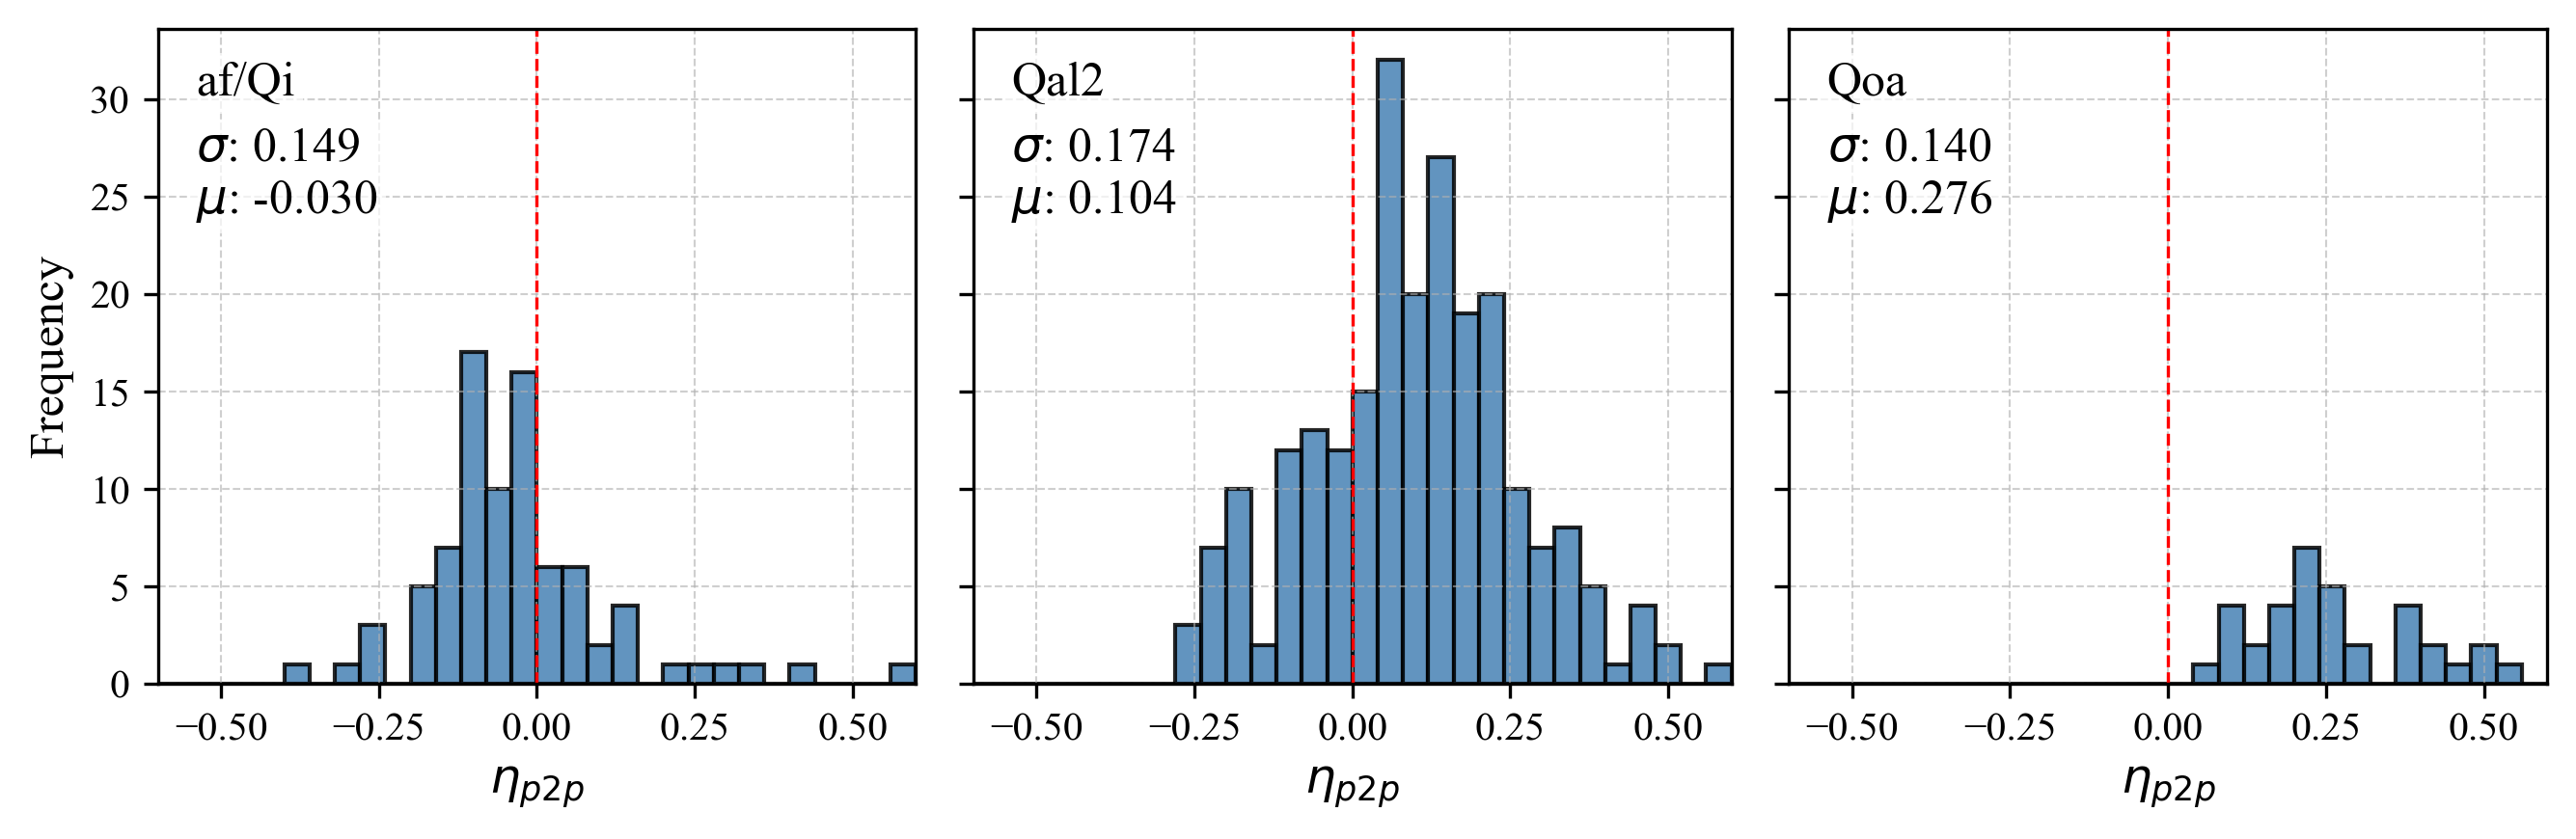

In [ ]:
from matplotlib.ticker import NullFormatter

# target_geology = ['Beach_Dune', 'Floodplain','Glacial', 'Lagoonal', 'Valley_Train', 'af/Qi', 'Qal1', 'Qal2', 'Qal3', 'Qoa', 'Qs']
target_geology = ['af/Qi', 'Qal2', 'Qoa']

df_plot = df_eta_p.copy()
df_plot['Geology_clean'] = df_plot['Group'].astype(str).str.strip()

geology_groups = df_plot[df_plot['Geology_clean'].isin(target_geology)].groupby('Geology_clean')

fig, axes = plt.subplots(1, 3, figsize=(9, 3), dpi=300, sharey=True)

for ax, geology in zip(axes, target_geology):
    ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.6)
    group = df_plot[df_plot['Geology_clean'] == geology]

    if group.empty:
        ax.text(0.5, 0.5, f'{geology}\n(no data)', ha='center', va='center', transform=ax.transAxes)
    else:
        ax.hist(
            group['eta_p'],
            bins=np.linspace(-0.6, 0.6, 31),
            color='steelblue',
            edgecolor='black',
            alpha=0.85
        )

    ax.axvline(0, color='red', linestyle='--', linewidth=0.8)
    ax.set_xlim(-0.6, 0.6)
    ax.set_xticks(np.arange(-0.5, 0.6, 0.25))
    ax.set_xlabel('$\eta_{p2p}$', fontsize=12)
    ax.text(
        0.05, 0.95, f'{geology}',
        transform=ax.transAxes,
        ha='left', va='top',
        fontsize = 12,
        bbox=dict(facecolor='white', edgecolor='none', alpha=0.7, pad=2)
    )

    if not group.empty:
        mean_eta = group['eta_p'].mean()
        std_eta = group['eta_p'].std()
        annotation = (
            rf"$\sigma$: {std_eta:.3f}" "\n"
            rf"$\mu$: {mean_eta:.3f}"
        )

        ax.text(
            0.05, 0.85, annotation,
            transform=ax.transAxes,
            ha='left',
            va='top',
            fontsize=12,
            bbox=dict(
            facecolor='white',
            edgecolor='none',
            alpha=0.7,
            pad=2
            )
        )

axes[0].set_ylabel('Frequency', fontsize=12)


plt.tight_layout()
plt.show()

fig.savefig('eta_p_ML_no_geo_histogram.png', dpi=300, bbox_inches='tight')

#### Regression 3: Geology + Profile (In the paper)

In [ ]:
import numpy as np
from scipy.optimize import least_squares
import time

def calculation_mixed(x, Qtncs_CPT_valid, fz_CPT_valid, Ic_CPT_valid, lay_id_assign_valid, tt_ids, group_filters, Vsi):

    f_Ic_constrain = 0.1 + 0.4 * (1 / (1 + np.exp(-x[1] * (Ic_CPT_valid - x[2]))))    
    cpt_velocity = x[0] * np.log(Qtncs_CPT_valid) + f_Ic_constrain * np.log(fz_CPT_valid) + sum(group_filters[group] * x[2 + group] for group in group_filters)
    
    cpt_slowness = 1 / np.exp(cpt_velocity)
    dz = np.repeat(0.05, len(cpt_velocity))

    layer_slowness = np.bincount(lay_id_assign_valid, weights = cpt_slowness * dz)
    layer_thickness = np.bincount(lay_id_assign_valid, weights = dz)
    layer_velocity = layer_thickness / layer_slowness

    layer_velocity = layer_thickness / layer_slowness

    residual = np.log(Vsi) - np.log(layer_velocity)

    unique_tt_ids = np.unique(tt_ids)
    eta_p = np.empty(len(residual), dtype=float)
    for i, unique_tt_id in enumerate(unique_tt_ids):
            eta_p[tt_ids == unique_tt_id] = np.full(len(tt_ids[tt_ids == unique_tt_id]), np.mean(residual[tt_ids == unique_tt_id]))

    Likelihood = L_normal_pdf(residual - eta_p, 0.0, x[15]) + L_normal_pdf(residual, 0, np.sqrt(x[14] ** 2 + x[15] ** 2))
    return -Likelihood

In [ ]:
x0 = [0.27, 2.3, 2.6] + [4.1] * len(unique_geology_ids) + [0.2, 0.2]

start_time = time.time()
bounds = ((-10, 10), (-10, 10), (-10, 10)) + ((-10, 10),) * len(unique_geology_ids) + ((0.01, 1.0), (0.01, 1.0))


result = sp.optimize.minimize(calculation_mixed, x0, args=(Qtncs_CPT_valid, fz_CPT_valid, Ic_CPT_valid, lay_id_assign_valid, tt_ids, group_filters, Vsi), bounds = bounds, method='L-BFGS-B')
end_time = time.time()

b1, b2, b3, *group_effects, phi_p2p, phi_ep = result.x

print(f"Regression completed in {end_time - start_time:.2f} seconds")
print ("Fixed effects:")
print(f"b1 = {b1:.2f}")
print(f"b2 = {b2:.2f}")
print(f"b3 = {b3:.2f}")
for i, group in enumerate(unique_geology_ids):
    print(f"Group {group} ({group_text[group_ids == group][0]}): a = {result.x[3 + i]:.4f}")
print("\nRandom effects summary:")
print(f"phi_p2p: {phi_p2p:.4f}")
print(f"phi_ep: {phi_ep:.4f}")
print(f"sigma: {np.sqrt(phi_p2p**2 + phi_ep**2):.4f}")

Regression completed in 70.73 seconds
Fixed effects:
b1 = 0.24
b2 = 2.45
b3 = 2.49
Group 1 (Beach_Dune): a = 4.3507
Group 2 (Floodplain): a = 4.2189
Group 3 (Glacial): a = 4.1648
Group 4 (Lagoonal): a = 4.1573
Group 5 (Valley_Train): a = 4.1913
Group 6 (af/Qi): a = 4.2170
Group 7 (Qal1): a = 4.3007
Group 8 (Qal2): a = 4.3684
Group 9 (Qal3): a = 4.3051
Group 10 (Qoa): a = 4.5276
Group 11 (Qs): a = 4.3528

Random effects summary:
phi_p2p: 0.1297
phi_ep: 0.1939
sigma: 0.2333


In [144]:
np.sqrt(phi_p2p**2 + phi_ep**2)

0.23326036806569075

In [ ]:
x = result.x

f_Ic_constrain = 0.1 + 0.4 * (1 / (1 + np.exp(- x[1] * (Ic_CPT_valid - x[2]))))

pred = x[0] * np.log(Qtncs_CPT_valid) + f_Ic_constrain * np.log(fz_CPT_valid) + sum(group_filters[group] * x[2 + group] for group in group_filters)

cpt_slowness = 1 / np.exp(pred)
dz = np.repeat(0.05, len(pred))
layer_slowness = np.bincount(lay_id_assign_valid, weights = cpt_slowness * dz)
layer_thickness = np.bincount(lay_id_assign_valid, weights = dz)
layer_velocity = layer_thickness / layer_slowness

R = np.log(Vsi) - np.log(layer_velocity)

unique_tt_ids = np.unique(tt_ids)
eta_p = np.empty(len(R), dtype=float)
for i, unique_tt_id in enumerate(unique_tt_ids):
        eta_p[tt_ids == unique_tt_id] = np.full(len(tt_ids[tt_ids == unique_tt_id]), np.mean(R[tt_ids == unique_tt_id]))

eta_p_unique = np.array([eta_p[tt_ids == i][0] for i in unique_tt_ids])

eta_wp = R - eta_p

df_profile_term_ML = pd.DataFrame({
    'travelTimeMeta_ID': unique_tt_ids,
    'eta_p': eta_p_unique
})

df_eta_ML = pd.DataFrame({
    'travelTimeMeta_ID': tt_ids,
    'eta_p': eta_p, 
    'eta_wp': eta_wp
})

In [157]:
np.std(eta_p)

0.12965412028673223

In [158]:
np.std(eta_wp)

0.19390624048856908

In [161]:
# export df_eta_p_ML to csv
df_profile_term_ML.to_csv("eta_p_ML.csv", index=False, header=True)

# export df_eta_wp_ML to csv
df_eta_ML.to_csv("eta_wp_ML.csv", index=False, header=True)

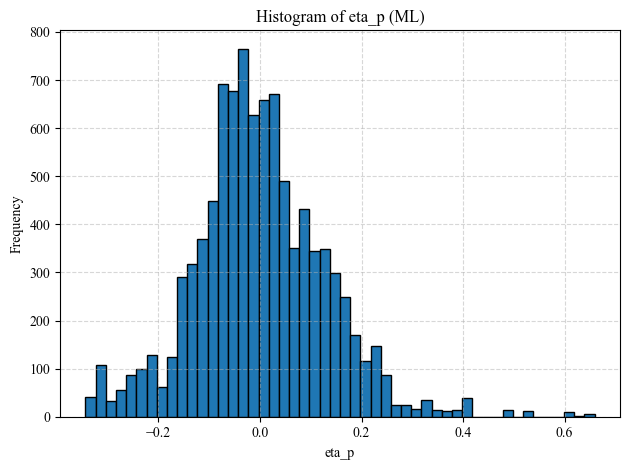

In [164]:
# plot out histogram of eta_p
plt.hist(eta_p, bins=50, edgecolor='black')
plt.xlabel('eta_p')
plt.ylabel('Frequency')
plt.title('Histogram of eta_p (ML)')
plt.grid(True, linestyle='--', alpha=0.5)
# plt.xlim(-0.6, 0.6)
plt.tight_layout()
plt.show()

In [ ]:
df_eta_p = pd.read_csv("eta_p_ML.csv")

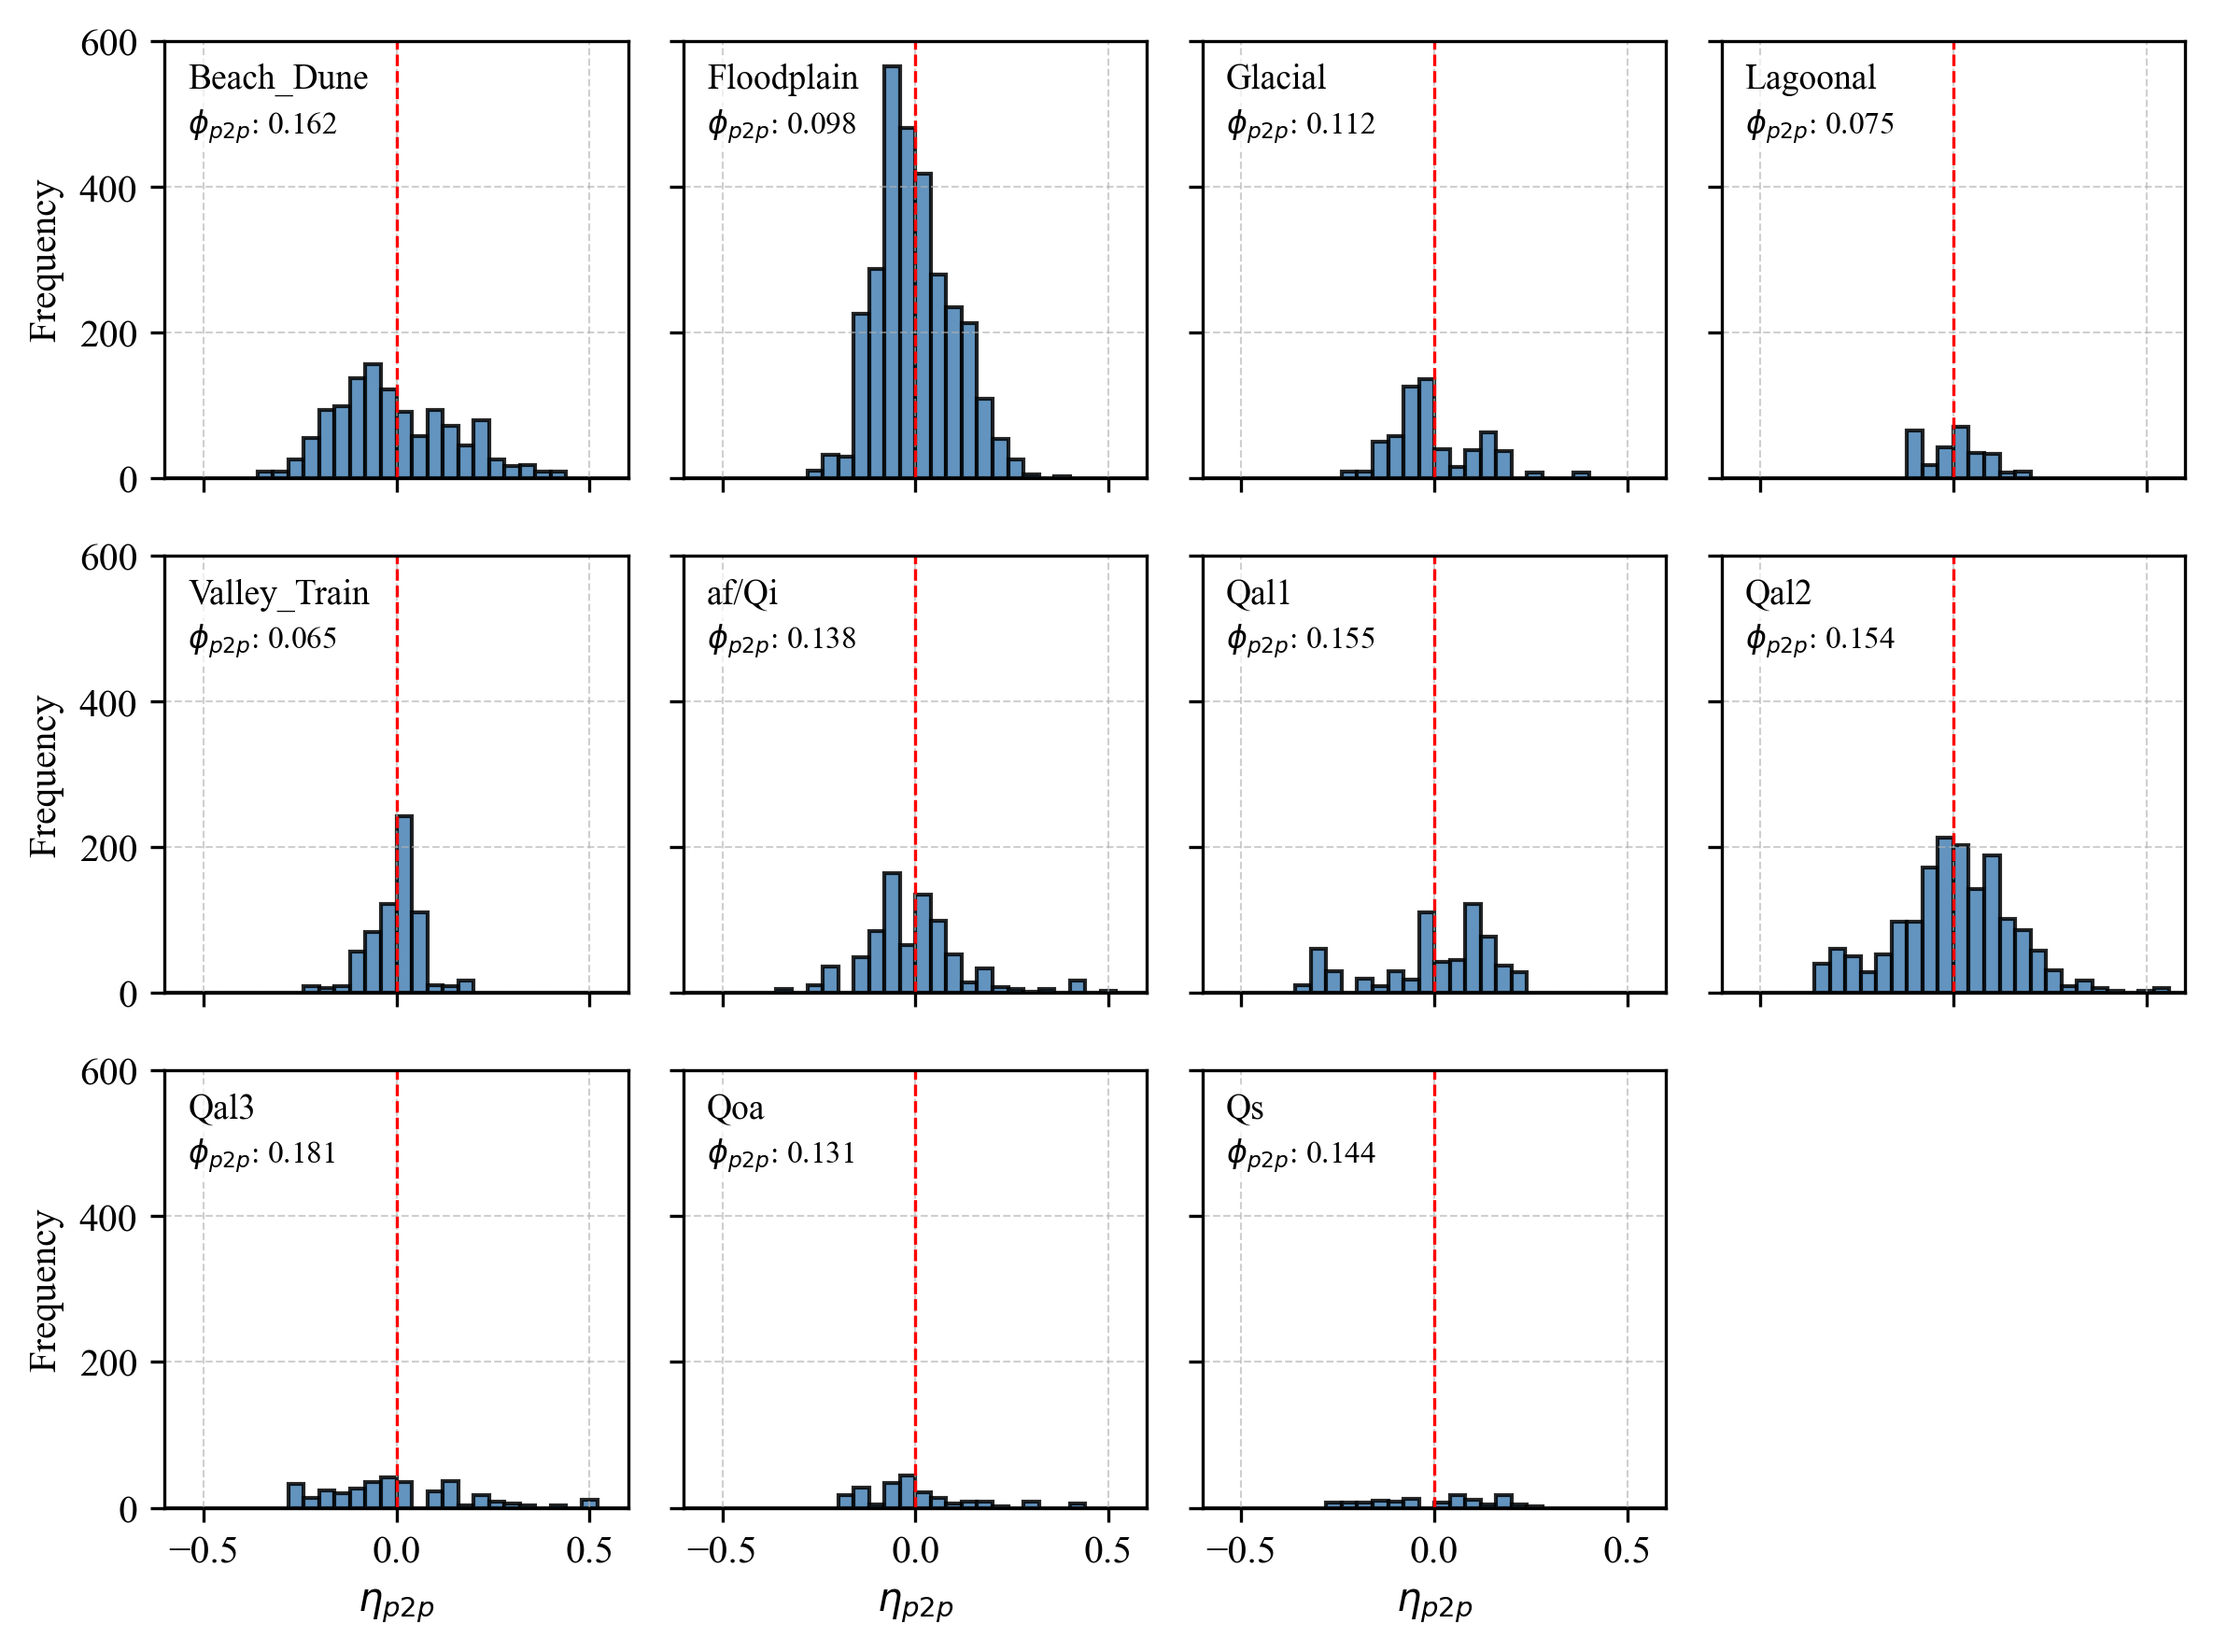

In [ ]:
from matplotlib.ticker import NullFormatter

target_geology = ['Beach_Dune', 'Floodplain','Glacial', 'Lagoonal', 'Valley_Train', 'af/Qi', 'Qal1', 'Qal2', 'Qal3', 'Qoa', 'Qs']

df_plot = df_eta_p.copy()
df_plot['Geology_clean'] = df_plot['Group'].astype(str).str.strip()

geology_groups = df_plot[df_plot['Geology_clean'].isin(target_geology)].groupby('Geology_clean')

fig, axes = plt.subplots(3, 4, figsize=(8, 6), dpi=300, sharex=True, sharey=True)
axes = axes.flatten()

for ax, geology in zip(axes, target_geology):
    ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.6)
    group = df_plot[df_plot['Geology_clean'] == geology]

    if group.empty:
        ax.text(0.5, 0.5, f'{geology}\n(no data)', ha='center', va='center', transform=ax.transAxes)
    else:
        ax.hist(
            group['eta_p'],
            bins=np.linspace(-0.6, 0.6, 31),
            color='steelblue',
            edgecolor='black',
            alpha=0.85
        )

    ax.axvline(0, color='red', linestyle='--', linewidth=0.8)
    ax.set_xlim(-0.6, 0.6)
    ax.set_ylim(0, 600)
    ax.text(
        0.05, 0.95, f'{geology}',
        transform=ax.transAxes,
        ha='left', va='top',
        fontsize=9,
        bbox=dict(facecolor='white', edgecolor='none', alpha=0.7, pad=2)
    )
    if not group.empty:
        mean_eta = group['eta_p'].mean()
        std_eta = group['eta_p'].std()
        ax.text(
            0.05, 0.85, r'$\phi_{p2p}$: ' f'{std_eta:.3f}',
            transform=ax.transAxes,
            ha='left', va='top',
            fontsize=8,
            bbox=dict(facecolor='white', edgecolor='none', alpha=0.7, pad=2)
        )

nrows, ncols = 3, 4

for i, ax in enumerate(axes):
    row, col = divmod(i, ncols)

    if row == 2:
        ax.set_xlabel('$\eta_{p2p}$')
    else:
        ax.set_ylabel('')

axes[0].set_ylabel('Frequency')
axes[4].set_ylabel('Frequency')
axes[8].set_ylabel('Frequency')


fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

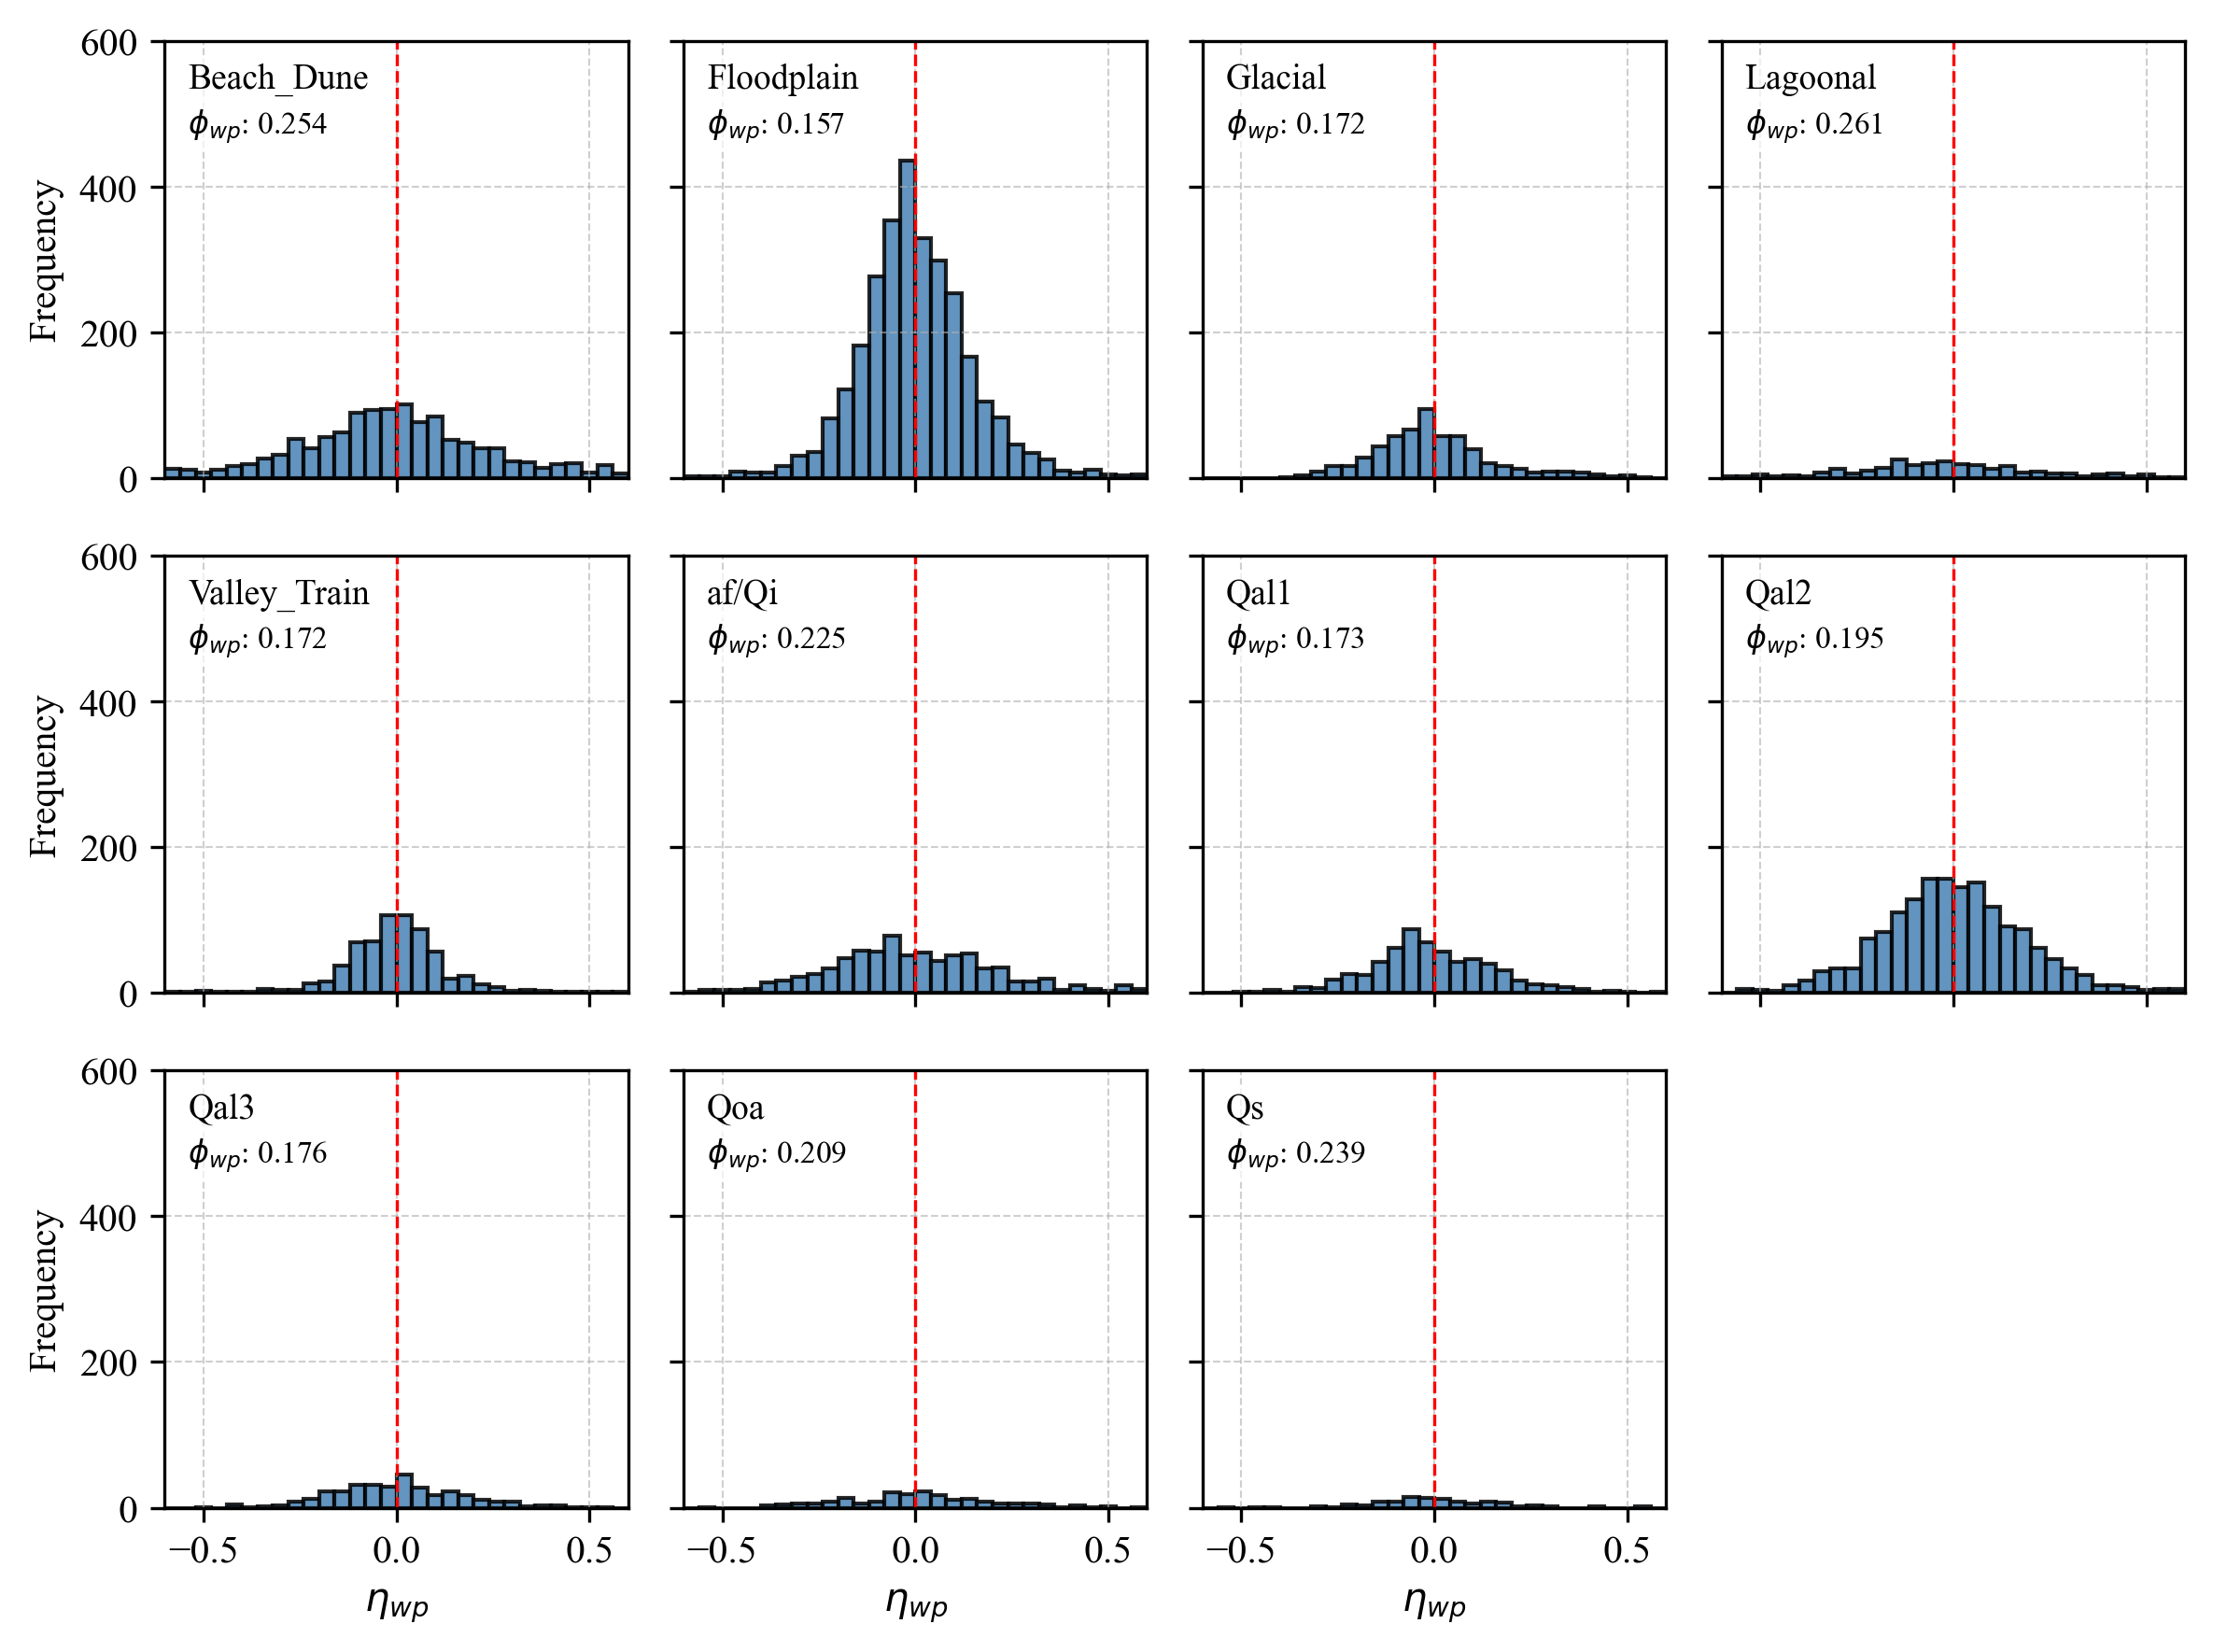

In [ ]:
from matplotlib.ticker import NullFormatter

df_plot = df_eta_p.copy()
df_plot['Geology_clean'] = df_plot['Group'].astype(str).str.strip()

geology_groups = df_plot[df_plot['Geology_clean'].isin(target_geology)].groupby('Geology_clean')

fig, axes = plt.subplots(3, 4, figsize=(8, 6), dpi=300, sharex=True, sharey=True)
axes = axes.flatten()

for ax, geology in zip(axes, target_geology):
    ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.6)
    group = df_plot[df_plot['Geology_clean'] == geology]

    if group.empty:
        ax.text(0.5, 0.5, f'{geology}\n(no data)', ha='center', va='center', transform=ax.transAxes)
    else:
        ax.hist(
            group['eta_wp'],
            bins=np.linspace(-0.6, 0.6, 31),
            color='steelblue',
            edgecolor='black',
            alpha=0.85
        )

    ax.axvline(0, color='red', linestyle='--', linewidth=0.8)
    ax.set_xlim(-0.6, 0.6)
    ax.set_ylim(0, 600)
    ax.text(
        0.05, 0.95, f'{geology}',
        transform=ax.transAxes,
        ha='left', va='top',
        fontsize=9,
        bbox=dict(facecolor='white', edgecolor='none', alpha=0.7, pad=2)
    )
    if not group.empty:
        mean_eta = group['eta_wp'].mean()
        std_eta = group['eta_wp'].std()
        ax.text(
            0.05, 0.85, r'$\phi_{wp}$: ' f'{std_eta:.3f}',
            transform=ax.transAxes,
            ha='left', va='top',
            fontsize=8,
            bbox=dict(facecolor='white', edgecolor='none', alpha=0.7, pad=2)
        )

nrows, ncols = 3, 4

for i, ax in enumerate(axes):
    row, col = divmod(i, ncols)

    if row == 2:
        ax.set_xlabel('$\eta_{wp}$')
    else:
        ax.set_ylabel('')

axes[0].set_ylabel('Frequency')
axes[4].set_ylabel('Frequency')
axes[8].set_ylabel('Frequency')


fig.delaxes(axes[-1]) 

plt.tight_layout()
plt.show()